# 15장 — LangGraph로 QA 에이전트 만들기

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning) **15장** |
| **해설 원본** | [15_..._ko_explained.md 열기](../../15_building_a_qa_agent_with_langgraph_ko_explained.md) |
| **원서 원문** | [15_....md 열기](../../15_building_a_qa_agent_with_langgraph.md) |
| **이 폴더** | [app.py](./app.py) · [chains/](./chains) · [tools/](./tools) · [importer/](./importer) |
| **원서 저장소** | [alenegro81/.../chapters/ch17 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch17) |
| **소스 폴더 번호** | 이 저장소는 소스 폴더에 **책 장 번호** 를 쓴다 — 이 장은 `src/ch15/` 다. 업스트림에서는 같은 코드가 `chapters/ch17` 에 있다 (MEAP 번호). 변환표는 `study.toml` 의 `[mapping.upstream_dirs]` 가 정본이다 |
| **리스팅 번호** | 책과 같다 (15.1\~15.15). 다만 `listings/` 디렉터리가 없고 코드가 애플리케이션 구조(`app.py`·`chains/`·`tools/`) 그대로 흩어져 있어, `study.toml` 이 번호 대신 `path` + `symbol` 로 선언한다 |
| **외부 서비스** | **Neo4j Enterprise**(시드 DB `chicago`) · **채팅 LLM 엔드포인트**. 「실행 환경」 절 참고 |
| **선행 조건** | 없다. 이 장은 **자기 데이터를 스스로 가져온다** — 공개 백업 URL 에서 `chicago` DB 를 시드한다. 6장 KG 에 의존하던 13장과 다르다 |

---

13장은 KG 를 **LLM 의 검색 근거** 로 썼고, 14장은 자연어 질문을 Cypher 로 옮기는 방법을 논했다. 15장은 그 둘을 **하나의 실행 가능한 애플리케이션** 으로 조립한다. 책의 마지막 장이고, 이 장이 끝나면 "질문을 받아 그래프를 조회하고 시각화와 요약을 돌려주는 시스템" 이 실제로 돈다.

이 장의 핵심 주장은 하나다 — **LLM 하나에게 "이 질문을 Cypher 로 바꿔라" 라고 시키지 말고, 전문가가 하는 일을 단계로 쪼개 각 단계에 전용 에이전트를 붙여라.**

| 단계 | 에이전트 | 이 단계가 없으면 |
| --- | --- | --- |
| ① 의도 감지 | `intent_detection` | 결과를 그래프로 그릴지 지도로 찍을지 표로 낼지 모른다 |
| ② 스키마 추출 | `schema_extraction` | LLM 이 존재하지 않는 라벨·속성으로 질의를 짠다 |
| ③ 텍스트→Cypher | `text_to_cypher` | — (이것만 하는 것이 순진한 구현이다) |
| ④ 질의 실행 | `query_execution` | 문법 오류가 그대로 사용자에게 간다 |
| ⑤ 실행 후 라우팅 | `post_query_execution` | 실패해도 재시도하지 않고, 요약이 필요한지 판단하지 못한다 |
| ⑥ 요약 생성 | `generate_summary` | 노드 뭉치만 던져 주고 끝난다 |

> **한 문장 요약** — 질문 하나를 Cypher 하나로 바꾸는 일을 단일 프롬프트에 맡기는 대신 **의도·스키마·생성·실행·라우팅·요약** 여섯 단계로 쪼개고 각 단계를 LangGraph 의 공유 상태로 이어 붙이면, 각 에이전트가 자기 일만 하면서도 **실패한 질의를 스스로 고쳐 재시도** 하고 결과 형태에 맞는 시각화까지 고르는 시스템이 된다.

### LangGraph 를 왜 쓰나 — 상태로 소통한다

에이전트끼리 데이터를 직접 주고받지 않는다. 각 에이전트는 **공유 상태(shared state)** 를 읽고 쓴다. 그래서 에이전트들이 서로를 모른 채 결합 없이 협업하고, 새 단계를 끼워 넣어도 기존 코드를 고칠 필요가 없다. 이 장의 상태는 `AgentState`(책 15.5) 하나이고, 파이프라인은 유향 그래프(책 15.12)로 조립된다.

### 절 구성

| 절 | 내용 | 리스팅 |
| --- | --- | --- |
| 15.1 | LangGraph 파이프라인 구축 | |
| 15.1.1 | 시스템 아키텍처 개요 | — |
| 15.1.2 | 파이프라인 구성요소 설정 (프롬프트·주석의 중앙 저장소) | 15.1 · 15.2 |
| 15.1.3 | 스키마 번역 서비스 (기술 스키마 → 개념 스키마) | 15.3 · 15.4 |
| 15.1.4 | 상태 관리 설계 | 15.5 |
| 15.1.5 | 파이프라인 에이전트 여섯 + 조립 | 15.6\~15.12 |
| 15.1.6 | 파이프라인 통합 계층 (이벤트 스트림) | 15.13 |
| 15.2 | Streamlit 애플리케이션 | 15.14 · 15.15 |
| 15.3 | 전문가 모방 수사 — 실제 사건 따라가기 | — |
| 15.4 | 향후 방향과 개선 | — |
| — | 실습 셋과 요약 | |

### 이 장의 수치는 비결정적이다

**LLM 이 매 단계에 관여하므로 재실행하면 생성 Cypher 도 요약 문장도 달라진다.** 그래서 이 노트북의 표는 단일값이 아니라 **관측 범위** 를 적고, 비교할 때는 문장이 아니라 **질의가 돌려준 레코드 수와 사용한 라벨·관계** 를 본다. 결정적인 것은 그래프 데이터 자체(시드 백업은 집필 시점 스냅샷이다)와 스키마 추출뿐이다.

---
## 실행 환경 — Neo4j Enterprise 시드 DB 하나와 채팅 엔드포인트 하나

이 장은 13장보다 의존이 **적다**. 임베딩 엔드포인트가 필요 없고, 다른 장이 만든 데이터에 기대지도 않는다.

| 필요한 것 | 없으면 막히는 것 | 왜 |
| --- | --- | --- |
| **Neo4j Enterprise + APOC** | 책 15.4 이후 전부 | `Neo4jSchema.get_schema()` 가 `apoc.meta.schema` 를 부른다. Enterprise 인 이유는 시드 자체가 Enterprise 전용 기능이다 |
| **`chicago` 시드 DB** | 책 15.4 이후 전부 | 이 장의 데이터. 아래 1번 |
| **채팅 LLM 엔드포인트** | 책 15.6\~15.13 | 에이전트 여섯 중 넷이 LLM 을 부른다 |

### 1. 데이터 — 공개 백업에서 `chicago` DB 를 시드한다

이 장은 데이터를 **스스로 가져온다.** Neo4j Enterprise 의 `CREATE DATABASE ... seedUri` 가 공개 URL 에서 백업을 내려받아 새 DB 를 만든다. API 키가 필요 없다.

```bash
cd chapter_15_building_a_qa_agent_with_langgraph/src/ch15
../../../.venv/bin/python importer/import_seed.py -d chicago
```

> ⚠️ **`-d chicago` 를 반드시 넘겨라.** `GraphDBBase` 의 `database` 기본값이 `'neo4j'` 여서, 인자 없이 돌리면 `CREATE DATABASE neo4j` 가 된다. 그 이름은 **6장 임포터가 만든 KG 와 13장이 쓴 벡터 임베딩** 이 들어 있는 기존 DB 다. 기존 DB 가 있으면 `CREATE DATABASE` 가 실패하므로 데이터가 지워지지는 않지만 시드도 되지 않는다. 업스트림 `Readme.md` 는 이 옵션을 안내하지 않는다 ([`errata.toml`](../../../errata.toml) 등재).

내려받는 백업은 **223 MB**(`downloads.graphaware.com`)이고 Neo4j 서버가 직접 가져온다. 시드된 그래프는 시카고 범죄·차량번호인식(ANPR) 데이터다.

| 노드 | 개수 | | 관계 | 개수 |
| --- | --- | --- | --- | --- |
| `Vehicle` | 1797 | | `ARRESTED_DURING` | 221 |
| `Arrest` | 221 | | `ARREST_RELATED_TO_CASE` | 187 |
| `ANPRCamera` | 161 | | `COMMITTED` | 183 |
| `Case` | 124 | | `OCCURRED_AT` | 123 |
| `Crime` | 123 | | `CRIME_RELATED_TO_CASE` | 122 |
| `Location` | 73 | | `CO_OFFENDS_WITH` | 103 |
| `Person` | 63 | | `OWNED_BY` | 50 |
| `ANPRCameraEvent` | 40 | | `HAS_EVENT` · `PLATE_READ_EVENT` | 40 · 40 |

시드 백업은 **집필 시점 스냅샷** 이라 책의 화면과 같은 데이터를 본다 — 원본에서 새로 받는 데이터가 아니므로 드리프트가 없다.

### 2. Neo4j 컨테이너

```bash
docker ps --filter name=kglm-neo4j-ee     # Up 상태여야 한다
```

검증 환경은 **Enterprise 5.26.28 · APOC 5.26.28** 이다. 접속 정보는 교재 루트의 [`config.ini`](../../../config.ini) 가 정본이지만, 이 챕터 코드는 `config.ini` 대신 환경변수(`NEO4J_URI`·`NEO4J_USER`·`NEO4J_PASSWORD`·`NEO4J_DATABASE`)를 읽는다. 아래 점검 셀이 채워 준다.

### 3. 패키지 — 이 노트북에 필요한 것은 `langgraph` 하나뿐이다

업스트림 [`requirements.lock`](./requirements.lock) 은 아홉 개를 pin 하지만, **그중 여섯은 `app.py` 전용** 이다. 이 노트북은 Streamlit 앱을 띄우지 않고 파이프라인만 조립하므로 설치하지 않는다.

| 패키지 | 업스트림 pin | 이 노트북 검증 버전 | 판정 |
| --- | --- | --- | --- |
| `langgraph` | `0.2.19` | **0.2.19** | 그대로 설치. 제약이 `langchain-core<0.4,>=0.2.38` 이라 현재 0.3.86 과 맞는다 |
| `neo4j` | `4.4.11` | **5.28.4** | **다운그레이드하지 않는다** — 완성된 챕터들이 5.28.4 에서 실행돼 출력이 커밋됐다 |
| `openai` | `1.12.0` | **1.69.0** | 같은 이유 |
| `langchain-openai` | `0.2.8` | **0.3.23** | 같은 이유 |
| `langchain-ollama` | `0.2.0` | **0.3.10** | 이 노트북은 쓰지 않는다 |
| `streamlit` · `streamlit-d3graph` · `d3graph` · `scikit-learn` | 있음 | **설치 안 함** | `app.py` 전용 |
| `folium` · `st_link_analysis` · `streamlit_folium` · `json5` | **lock 에 없음** | `json5` 만 있음 | `app.py` 가 임포트하는데 lock 에서 빠졌다 (업스트림 누락) |

```bash
.venv/bin/pip install 'langgraph==0.2.19'
```

설치 시 `langgraph` · `langgraph-checkpoint 1.0.12` · `msgpack 1.2.1` 셋만 추가되고 **기존 버전은 하나도 바뀌지 않는 것** 을 dry-run 으로 확인했다.

### 4. 업스트림을 고치지 않고 돌리기 위한 장치 **둘**

이 챕터는 그대로는 임포트조차 되지 않는다. 원본 파일은 한 글자도 고치지 않고 런타임에만 우회한다. 둘 다 [`errata.toml`](../../../errata.toml) 에 등재돼 있다.

**(a) `AzureChatOpenAI` 가 임포트 시점에 만들어진다**

[`chains/investigator.py`](./chains/investigator.py) L38 은 모듈 최상위에서 `AzureChatOpenAI(azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT"], …)` 를 실행한다. Azure 환경변수가 없으면 **`KeyError` 로 모듈 임포트 자체가 실패** 해서, 파일 위쪽에 주석으로 준비된 Ollama·OpenAI 대안까지 갈 수조차 없다.

→ 자리표시자 네 개를 채워 임포트만 통과시킨 뒤(생성자는 API 를 호출하지 않는다), `chain.abot.model` 을 프록시를 가리키는 `ChatOpenAI` 로 갈아끼운다.

**(b) `jinja2_formatter` 가 샌드박스라 템플릿의 점 접근을 막는다**

`langchain-core 0.3.86` 의 `jinja2_formatter` 는 `_RestrictedSandboxedEnvironment` 를 쓴다. 그런데 업스트림 템플릿 셋이 dict 에 점으로 접근한다.

| 템플릿 | 접근 |
| --- | --- |
| [`text_to_cypher.template`](./chains/templates/text_to_cypher.template) | `annotations.examples` · `annotations.notes` · `e.question` · `e.answer` · `e.reasoning` · `node.label` |
| [`summary.template`](./chains/templates/summary.template) | `node.label` · `node.properties` |

그대로 두면 `text_to_cypher` 단계에서 `SecurityError: Access to attributes is not allowed in templates` 로 파이프라인이 죽는다. **책이 틀린 것이 아니라 집필 이후 langchain-core 가 보안 강화를 넣은 것** 이다(`status = "version-drift"`).

→ 모듈 전역의 `jinja2_formatter` 만 평범한 `jinja2.Environment` 렌더러로 교체한다. 템플릿은 저장소 안의 신뢰된 파일이므로 샌드박스가 필요 없다. 다운그레이드는 하지 않는다 — 13장이 같은 langchain-core 에서 실행돼 출력이 커밋됐다.

### 5. 실행 시간 감각

| 셀 | 하는 일 | 실측 |
| --- | --- | --- |
| 환경 점검 | 패키지·Neo4j·엔드포인트 확인 | 3\~10초 |
| 책 15.4 | `apoc.meta.schema` + 설정 적용 | 1초 미만 |
| 책 15.13 | 파이프라인 1회 완주 (LLM 3\~4회 호출) | **10\~20초** |
| 15.3 수사 시나리오 | 질문 4개 연속 | **40초\~2분** |
| 실습 15-C | 같은 질문 3회 반복 | **30초\~1분** |

### 6. 이 노트북의 리스팅 분류

LLM 을 부르는 리스팅은 저장소 밖 키가 필요하므로 깨끗한 환경에서 기본 설정 Run All 이 건너뛴다 → `optional`. Streamlit UI 리스팅(15.14 · 15.15)은 브라우저 앱이라 노트북에서 실행하는 것이 부적절하다 → `documented-only`. 자세한 분류는 마지막 요약 절에 있다.

In [1]:
"""환경 점검 — 이 셀이 통과하면 이후 모든 셀을 돌릴 수 있다.

확인 순서를 의존 순서와 맞췄다. 앞이 실패하면 뒤는 볼 것도 없다.
  1) 패키지          langgraph 가 있나, langchain-core 와 맞나
  2) Neo4j           chicago DB 가 online 이고 기대한 라벨이 있나
  3) LLM 엔드포인트   프록시가 응답하나
플래그 셋(HAS_NEO4J·HAS_LLM·RUN_PIPELINE)을 세워 이후 셀이 스스로 건너뛰게 한다.
"""
import os, sys, time, configparser, importlib.metadata as md
from pathlib import Path

HERE = Path.cwd()
assert HERE.name == "ch15", f"이 노트북은 src/ch15 에서 돌려야 한다: {HERE}"
sys.path.insert(0, str(HERE))          # chains/ · tools/ 를 임포트하려면 필요하다

# ---------------------------------------------------------------- 1) 패키지
print("── 패키지")
WANT = {"langgraph": "0.2.19", "langchain-core": None, "langchain-openai": None,
        "neo4j": None, "json5": None, "jinja2": None, "PyYAML": None}
missing = []
for name, pinned in WANT.items():
    try:
        v = md.version(name)
        note = f"  (업스트림 pin {pinned})" if pinned and v != pinned else ""
        print(f"   ✓ {name:18s} {v}{note}")
    except md.PackageNotFoundError:
        print(f"   ✗ {name:18s} 없음")
        missing.append(name)
if missing:
    print(f"\n   → .venv/bin/pip install {' '.join(missing)}")

# ---------------------------------------------------------------- 2) Neo4j
print("\n── Neo4j")
cfg = configparser.ConfigParser()
cfg.read(HERE.parents[2] / "config.ini")
p = cfg["neo4j"]
# 업스트림 코드는 config.ini 가 아니라 환경변수를 읽는다. 이미 있으면 존중한다.
os.environ.setdefault("NEO4J_URI", p.get("uri", "bolt://localhost:7687"))
os.environ.setdefault("NEO4J_USER", p.get("user", "neo4j"))
os.environ.setdefault("NEO4J_PASSWORD", p.get("password", "password"))
os.environ.setdefault("NEO4J_DATABASE", "chicago")   # 기본값 neo4j 를 쓰면 안 된다

NEO4J_DB = os.environ["NEO4J_DATABASE"]
HAS_NEO4J = False
COUNTS = {}
try:
    from neo4j import GraphDatabase
    drv = GraphDatabase.driver(os.environ["NEO4J_URI"],
                               auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]))
    with drv.session(database=NEO4J_DB) as s:
        COUNTS = {r["label"]: r["n"] for r in s.run(
            "MATCH (n) RETURN labels(n)[0] AS label, count(*) AS n ORDER BY n DESC")}
    WANT_LABELS = {"Crime", "ANPRCamera", "ANPRCameraEvent", "Vehicle", "Person", "Location"}
    lack = WANT_LABELS - set(COUNTS)
    if lack:
        print(f"   ✗ DB '{NEO4J_DB}' 에 라벨이 없다: {sorted(lack)}")
        print("     → python importer/import_seed.py -d chicago  (223MB 시드)")
    else:
        HAS_NEO4J = True
        print(f"   ✓ DB '{NEO4J_DB}' — " + " · ".join(f"{k} {v}" for k, v in list(COUNTS.items())[:5]))
    drv.close()
except Exception as exc:
    print(f"   ✗ 접속 실패: {type(exc).__name__}: {str(exc)[:110]}")
    print("     → docker start kglm-neo4j-ee")

# ---------------------------------------------------------------- 3) LLM
print("\n── LLM 엔드포인트")
HAS_LLM = False
try:
    from studykit import config, llm
    STUDY = config.load()
    print("   " + str(llm.configure(STUDY, model="gpt-5.4-mini")))   # 키는 마스킹된다
    HAS_LLM = bool(os.environ.get("OPENAI_API_KEY"))
except Exception as exc:
    print(f"   ✗ {type(exc).__name__}: {str(exc)[:110]}")

RUN_PIPELINE = HAS_NEO4J and HAS_LLM
print(f"\n── 플래그  HAS_NEO4J={HAS_NEO4J}  HAS_LLM={HAS_LLM}  RUN_PIPELINE={RUN_PIPELINE}")
if not RUN_PIPELINE:
    print("   LLM·Neo4j 셀은 건너뛴다. 리스팅 원문과 실측 기록은 그대로 읽을 수 있다.")

── 패키지
   ✓ langgraph          0.2.19
   ✓ langchain-core     0.3.86
   ✓ langchain-openai   0.3.23
   ✓ neo4j              5.28.4
   ✓ json5              0.15.0
   ✓ jinja2             3.1.6
   ✓ PyYAML             6.0.3

── Neo4j


   ✓ DB 'chicago' — Vehicle 1797 · Arrest 221 · ANPRCamera 161 · Case 124 · Crime 123

── LLM 엔드포인트
   {'base_url': 'http://localhost:8317/v1', 'model': 'gpt-5.4-mini', 'key': '설정됨 (14자)'}

── 플래그  HAS_NEO4J=True  HAS_LLM=True  RUN_PIPELINE=True


In [2]:
"""리스팅 접근 헬퍼와 "업스트림을 고치지 않고 돌리는" 장치 둘.

리스팅 위치의 정본은 study.toml 의 [mapping.listings.ch15] 이고, 그 선언을 해석하는
일은 공용 리더 studykit.listing_source 가 한다. 이 노트북은 대응표도 ast 헬퍼도
두지 않는다 — 노트북마다 재구현하면 정본이 이름만 남는다.

    listing_source.chunk_for(STUDY, "ch15", "15.4")   -> .text / .origin() / .path
    listing_source.cross_reference(STUDY, "ch15")     -> 대조표 한 줄씩 (.title 포함)
"""
import textwrap
from studykit import config, listing_source

STUDY = config.load()
REPO_DIR = "ch15"          # 소스 폴더 = 책 장 번호 (업스트림 MEAP 에서는 ch17)


def show(book_no, *, head=None):
    """책 리스팅 번호로 원문을 찍는다. head 를 주면 앞부분만."""
    chunk = listing_source.chunk_for(STUDY, REPO_DIR, book_no)
    print(f"# 책 리스팅 {book_no}  ←  {chunk.origin()}")
    print("# " + "-" * 76)
    lines = chunk.text.splitlines()
    for line in (lines[:head] if head else lines):
        print(line)
    if head and len(lines) > head:
        print(f"# … 이하 {len(lines) - head}줄 생략 (전체는 {chunk.rel_path})")
    return chunk


print("책 리스팅 -> 실제 위치  (study.toml 의 [mapping.listings.ch15] 가 정본)")
print("=" * 100)
XREF = listing_source.cross_reference(STUDY, REPO_DIR)
for row in XREF:
    print(f"  {row.number:>6}  {row.title[:40]:42s} {row.where}")
print(f"\nstudy.toml 이 선언한 {REPO_DIR} 리스팅 {len(XREF)}건")
print("  15.7 · 15.9 는 원서 md 에서 캡션이 유실돼 study.toml 이 title 을 함께 선언한다")

# ---------------------------------------------------------------- 장치 (a)
# investigator.py 는 모듈 최상위에서 AzureChatOpenAI 를 만든다. 값이 없으면 KeyError 로
# 임포트 자체가 실패하므로, 자리표시자를 채워 통과만 시킨다. 생성자는 API 를 부르지 않고,
# 실제로 쓸 모델은 임포트 뒤에 갈아끼운다. 업스트림 파일은 고치지 않는다.
for k, v in {"AZURE_OPENAI_API_KEY": "unused-placeholder",
             "AZURE_OPENAI_ENDPOINT": "http://localhost:1/",
             "AZURE_OPENAI_DEPLOYMENT": "unused-placeholder",
             "AZURE_OPENAI_API_VERSION": "2024-02-01"}.items():
    os.environ.setdefault(k, v)


def load_chain():
    """chains.investigator 를 임포트하고 두 장치를 적용한 모듈을 돌려준다."""
    import jinja2
    import chains.investigator as chain
    from langchain_openai import ChatOpenAI

    # (a) 프록시를 가리키는 ChatOpenAI 로 교체
    chain.abot.model = ChatOpenAI(model=os.environ["OPENAI_MODEL"],
                                  base_url=os.environ["OPENAI_BASE_URL"],
                                  api_key=os.environ["OPENAI_API_KEY"], temperature=0)

    # (b) 샌드박스 렌더러를 평범한 jinja2 로. 템플릿이 dict 에 점으로 접근하는데
    #     langchain-core 0.3.x 의 jinja2_formatter 는 그것을 SecurityError 로 막는다.
    #     템플릿은 저장소 안의 신뢰된 파일이라 샌드박스가 필요 없다.
    chain.jinja2_formatter = (
        lambda template, /, **kw: jinja2.Environment().from_string(template).render(**kw))
    return chain


def run_guarded(label, fn, *args, **kwargs):
    """LLM 호출 셀 가드. 프록시가 아파도 노트북이 죽지 않게 한다."""
    t0 = time.time()
    try:
        out = fn(*args, **kwargs)
        print(f"[{label}] OK  {time.time() - t0:.1f}초")
        return out
    except Exception as exc:
        print(f"[{label}] 실패 {time.time() - t0:.1f}초 — {type(exc).__name__}: {str(exc)[:160]}")
        return None

책 리스팅 -> 실제 위치  (study.toml 의 [mapping.listings.ch15] 가 정본)
    15.1  Configuration file example                 chains/chain_config.yaml  L1-L39
    15.2  Configuration component                    chains/investigator.py  L43-L62
    15.3  Schema provider: data model                tools/schema.py  L8-L69
    15.4  Schema provider main class                 tools/schema.py  L114-L178
    15.5  Pipeline agent’s state                     chains/investigator.py  L65-L85
    15.6  Intent detection agent implementation      chains/investigator.py  L113-L129
    15.7  Schema extraction agent                    chains/investigator.py  L131-L135
    15.8  Text-to-Cypher agent                       chains/investigator.py  L137-L148
    15.9  Query execution agent                      chains/investigator.py  L150-L170
   15.10  Post-query execution dynamic edge          chains/investigator.py  L172-L188
   15.11  Generate-summary agent                     chains/investigator.py  L190-L200
   15

---
## 15.1 LangGraph 파이프라인 — 에이전트는 서로를 모른 채 상태로 소통한다

이 장이 만드는 시스템의 전체 모습이 그림 15.1 이다. 사용자 입력(질문 + 화면에서 고른 노드)과 출력(시각화 + 요약)은 **Streamlit** 이 맡고, 그 사이의 실행 흐름은 **LangGraph** 가 조율한다. 14장에서 개념으로 논한 구조를 여기서 실제 코드로 옮긴다.

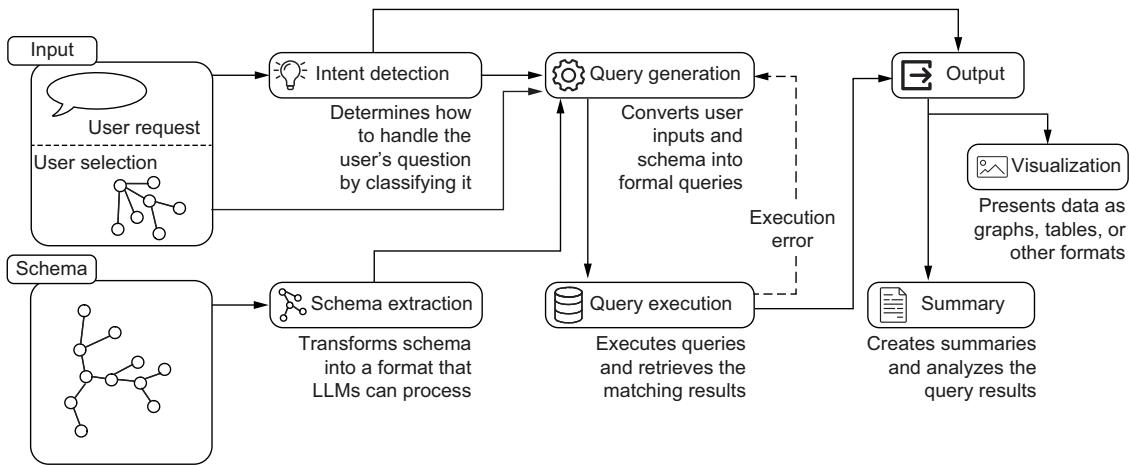

LangGraph 를 남다르게 만드는 것은 **구성요소끼리 소통하는 방식** 이다. 데이터를 함수에서 함수로 직접 넘기지 않는다. 각 에이전트는 **공유 상태(shared state)** 를 읽고 자기 결과를 거기 얹는다.

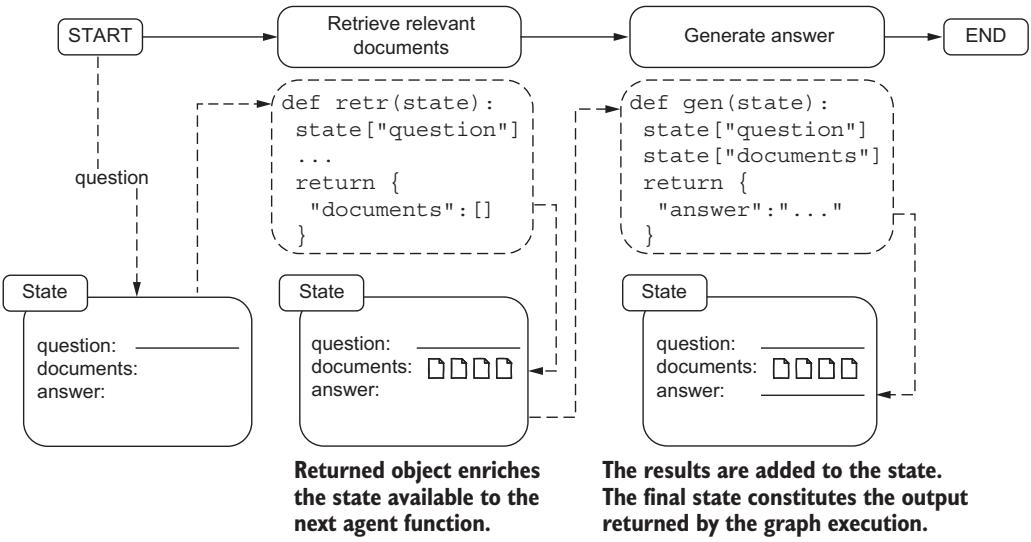

간단한 RAG 로 보면 이렇다. 상태는 사용자의 질문에서 출발한다. 문서 검색 에이전트가 상태에서 질문을 읽고 찾은 문서를 상태에 **추가** 한다. 그러면 답변 생성 에이전트는 질문과 문서를 **모두** 볼 수 있게 되고, 생성한 답을 다시 상태에 얹는다.

이 설계가 사는 이유는 **결합(coupling)이 없다** 는 데 있다. 검색 에이전트는 자기 뒤에 누가 오는지 모르고, 생성 에이전트는 문서가 어디서 왔는지 모른다. 그래서 단계를 끼워 넣거나 빼도 나머지 코드를 고칠 일이 없다. 이 장의 파이프라인이 에이전트 여섯을 갖고도 각각 10줄 안팎으로 끝나는 것이 그 결과다.

구조적으로 LangGraph 는 이 워크플로우를 **유향 그래프** 로 구현한다. 노드는 에이전트 함수이고, 엣지는 다음에 누구를 부를지다. 엣지가 **조건부** 일 수 있다는 점이 중요하다 — 이 장의 파이프라인은 질의가 실패하면 되돌아가 다시 시도한다(책 15.10).

이 스펙트럼의 한쪽 끝에는 LLM 이 여러 구성요소 중 하나에 불과한 **라우터** 시스템이 있고, 반대쪽 끝에는 LLM 이 실행 경로를 스스로 정하는 **완전 자율 에이전트** 가 있다. 이 장의 시스템은 **중간** 에 있다 — 경로는 사람이 그렸고, LLM 은 각 노드 안에서 판단만 한다.

---
### 15.1.1 시스템 아키텍처 — 전문가가 하는 일을 노드로 쪼갠다

그림 15.3 이 이 장의 파이프라인이다. 실선은 주 흐름(의도 감지 → 스키마 추출 → 질의 생성 → 질의 실행)이고, **점선이 조건부 경로** 다.

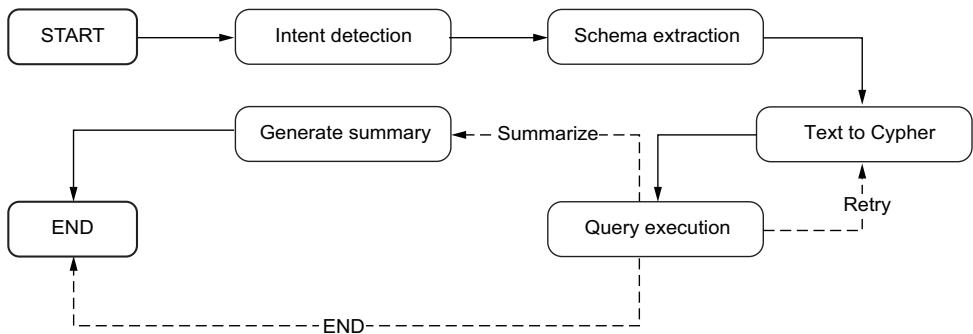

LangGraph 워크플로우는 백엔드의 중심이지만 혼자 돌지 않는다. 그림 15.4 가 더 넓은 그림이다.

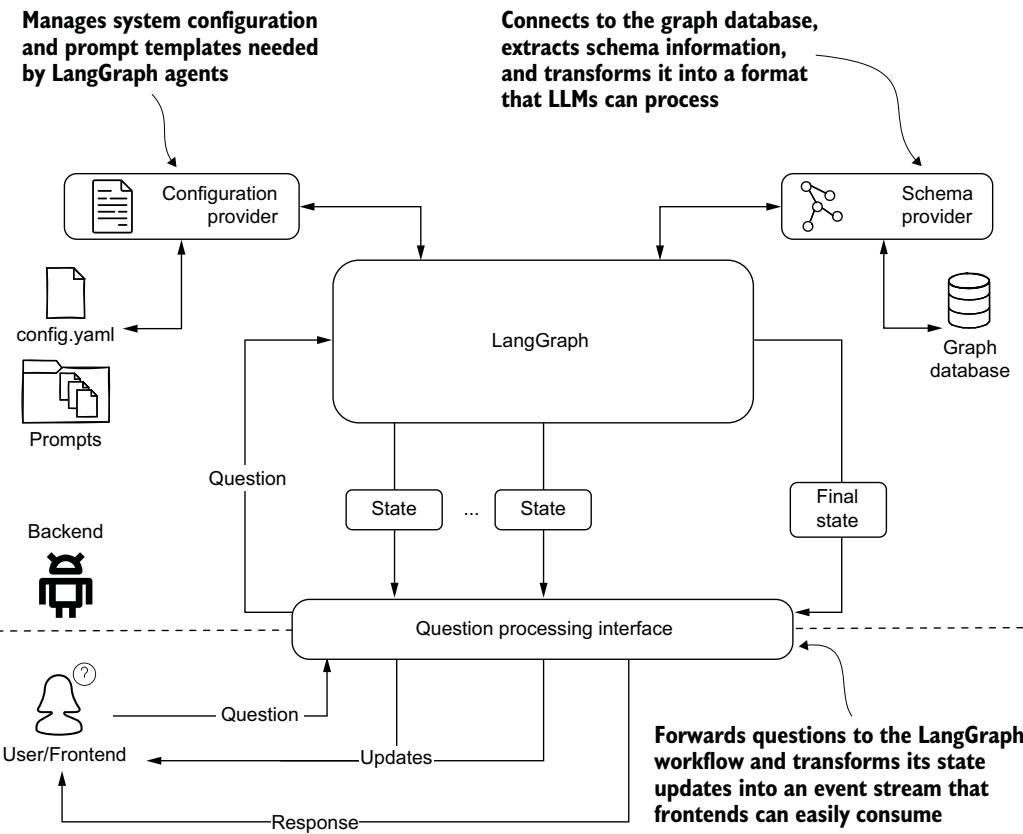

| 구성요소 | 책임 | 이 노트북의 리스팅 |
| --- | --- | --- |
| **설정 제공자** (configuration provider) | 프롬프트 템플릿과 KG 주석을 한곳에 모은다 | 15.1 · 15.2 |
| **스키마 제공자** (schema provider) | DB 의 기술 스키마를 LLM 이 읽을 개념 스키마로 번역한다 | 15.3 · 15.4 |
| **LangGraph 파이프라인** | 질의응답 핵심 로직 | 15.5\~15.12 |
| **질문 처리 인터페이스** | 파이프라인 실행을 **이벤트 스트림** 으로 노출해 프런트엔드가 진행 상황을 실시간으로 보여 주게 한다 | 15.13 |

관심사가 깔끔히 갈린다는 것이 요점이다. 아래에서 이 순서대로 하나씩 짚는다.

---
### 15.1.2 설정 구성요소 — 텍스트 자원을 한곳에 모은다

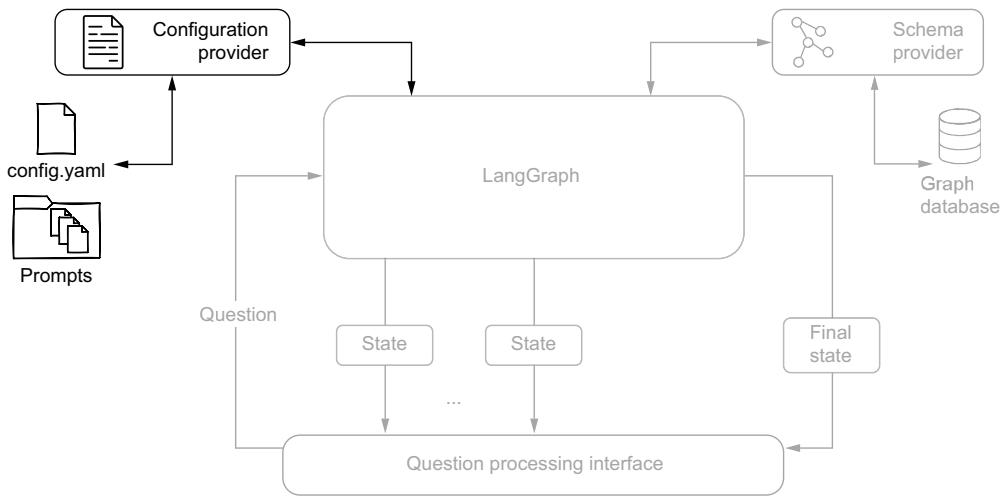

설정 구성요소는 시스템이 의존하는 **텍스트 자원의 중앙 저장소** 다. 두 가지가 들어간다.

| 무엇 | 왜 코드 밖에 두나 |
| --- | --- |
| **프롬프트 템플릿** (Jinja2) | 템플릿을 **작성하는 일** 과 **렌더링하는 일** 사이에 경계를 만든다. 핵심 코드는 깔끔해지고, 프롬프트는 코드를 건드리지 않고 고칠 수 있다 |
| **KG 주석** (`notes` · `examples`) | 스키마만으로는 LLM 이 알 수 없는 도메인 지식이다. "POINT 속성에는 `point.distance()` 를 쓸 수 있다", "상습범이란 범죄에 연결된 노드를 말한다" 같은 것 |

`examples` 는 특히 중요하다. 질문·정답 Cypher·근거를 묶은 **few-shot 예시** 이고, 이것이 `text_to_cypher` 프롬프트에 그대로 들어간다. 즉 **이 시스템의 질의 품질을 올리는 가장 싼 방법은 코드가 아니라 이 YAML 을 고치는 것** 이다.

In [3]:
"""책 15.1 · 15.2 — 설정 파일과 그것을 읽는 구성요소.

15.1 은 코드가 아니라 YAML 이라 파일 전체가 리스팅이다 (책은 [...] 로 줄여 실었다).
15.2 의 ChainConfiguration 이 그 파일을 읽어 프롬프트를 렌더링해 준다.
"""
show("15.1", head=14)
print()
show("15.2")

# 실제로 무엇이 들어 있는지 구조만 확인한다 (LLM·Neo4j 없이 되는 부분이다).
import yaml
cfg = yaml.safe_load((HERE / "chains" / "chain_config.yaml").read_text())
print("\n" + "=" * 78)
print("chain_config.yaml 최상위 키:", list(cfg))
print(f"  notes    : {len(cfg['notes'].splitlines())}줄의 도메인 규칙")
print(f"  examples : few-shot 예시 {len(cfg['examples'])}건")
for i, e in enumerate(cfg["examples"], 1):
    print(f"     {i}. Q: {e['question'][:64]}")
    print(f"        A: {' '.join(e['answer'].split())[:72]}")
print(f"  prompts  : {list(cfg['prompts'])}")
for name, spec in cfg["prompts"].items():
    print(f"     {name:18s} -> {spec['template']}")

# 책 리스팅 15.1  ←  chains/chain_config.yaml  L1-L39  (파일 전체)
# ----------------------------------------------------------------------------
notes: >
    - all POINTS properties are Neo4j Points (`point.distance()` and similar function works for them)
    - do not use path for single node expansion.
    - whenever you have to traverse one relationship, expand and return the entire path.
    - use path1,path2 and so on if you have to match multiple paths
    - do not expand ANPRCameraEvent unless you have to connect to both Vehicle and ANPRCamera
    - a previous offender o know offender is defined by the fact that it is connected to crimes.
examples:
    - question: Crimes that occurred on March 14th, 2025
      answer: MATCH (c:Crime)  WHERE c.date starts with "2025-03-14"
      reasoning: >-
          To find the crimes that occurred in that data we leverage the <b>date</b>  property of the crime node.
          Since it is formatted as ISO string we can use the prefix "2025-03-14" to g

---
### 15.1.3 스키마 번역 서비스 — 기술 스키마를 개념 스키마로

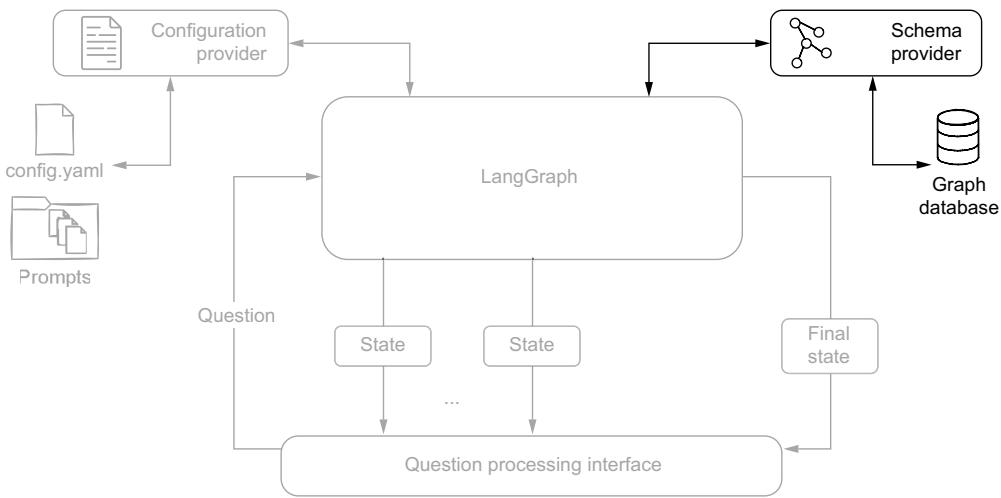

LLM 에게 "이 질문을 Cypher 로 바꿔라" 라고 시키려면 **그래프에 무엇이 있는지** 알려 줘야 한다. 그런데 `apoc.meta.schema` 가 돌려주는 것은 사람이 읽기 위한 것이 아니다 — 모든 속성, 모든 관계 방향, 내부 타입 정보가 전부 들어 있는 **기술 스키마** 다.

스키마 제공자가 하는 일은 그것을 **개념 스키마** 로 다듬는 것이다.

| 단계 | 하는 일 |
| --- | --- |
| `get_schema()` | `apoc.meta.schema({sample:-1})` 로 전수 조사한다. `sample:-1` 은 표집하지 말라는 뜻이라 작은 라벨도 빠지지 않는다 |
| `apply_configuration()` | [`tools/schema_config.yaml`](./tools/schema_config.yaml) 에 따라 **불필요한 속성을 버리고 설명을 붙인다** |
| `__str__()` | LLM 이 읽을 텍스트 형태로 조립한다 — `(:NodeType /* 설명 */ { prop:TYPE /* 설명 */ })` |

책 15.3 은 그 형태를 만드는 데이터 모델(`Property` · `Node`)이고, 15.4 가 그것을 쓰는 본체(`Neo4jSchema`)다.

> **참고** — 저장소의 `tools/schema.py` 에는 `Relationship` 클래스도 있지만 **책에는 실리지 않았다.** 원문이 "The Property class handles individual attributes …, and the Node class manages the overall structure" 라고 둘만 짚는다. 아래 15.3 출력이 책에 실린 범위(L8\~L69)와 정확히 일치하는 이유다.

In [4]:
"""책 15.3 — 스키마의 데이터 모델. Property 와 Node 두 dataclass 다."""
show("15.3")

# 책 리스팅 15.3  ←  tools/schema.py  L8-L69  (줄 범위)
# ----------------------------------------------------------------------------
@dataclass
class Property:
    """represents a node or relationship property with an optional description"""
    name: str
    type: str
    description: str = None

    def __str__(self):
        """represents the property as string in the format: propety_name:TYPE /* optional description */"""
        ret = f"{self.name}: {self.type}"
        if self.description is not None:
            ret += f" /* {self.description} */"
        return ret


@dataclass
class Node:
    """Represents a node type."""
    items = {}
    name: str
    properties: list[Property]
    description: str = None

    @classmethod
    def mk_node(cls, name, value):
        """Creates a new node with the given name and properties from a dictionary.

        Args:
            name (str): The name of the node.
            value (dict): the node description as returned by `apoc.meta.schema`

ListingChunk(text='@dataclass\nclass Property:\n    """represents a node or relationship property with an optional description"""\n    name: str\n    type: str\n    description: str = None\n\n    def __str__(self):\n        """represents the property as string in the format: propety_name:TYPE /* optional description */"""\n        ret = f"{self.name}: {self.type}"\n        if self.description is not None:\n            ret += f" /* {self.description} */"\n        return ret\n\n\n@dataclass\nclass Node:\n    """Represents a node type."""\n    items = {}\n    name: str\n    properties: list[Property]\n    description: str = None\n\n    @classmethod\n    def mk_node(cls, name, value):\n        """Creates a new node with the given name and properties from a dictionary.\n\n        Args:\n            name (str): The name of the node.\n            value (dict): the node description as returned by `apoc.meta.schema`\n        """\n        properties = [Property(name=k, type=v["type"]) for k, v i

In [5]:
"""책 15.4 — 스키마 제공자 본체. 그리고 실제로 chicago 그래프에 물려 돌려 본다.

이 셀은 LLM 을 부르지 않는다. Neo4j 만 있으면 결정적으로 재현된다.
"""
show("15.4", head=22)

if HAS_NEO4J:
    from tools.schema import Neo4jSchema

    schema = Neo4jSchema(os.environ["NEO4J_URI"],
                         (os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]),
                         NEO4J_DB)
    t0 = time.time()
    schema.get_schema()          # apoc.meta.schema 전수 조사
    raw_nodes = len(__import__("tools.schema", fromlist=["Node"]).Node.items)
    schema.apply_configuration() # schema_config.yaml 로 다듬기
    text = str(schema)
    print("\n" + "=" * 78)
    print(f"apoc.meta.schema 가 찾은 노드 타입: {raw_nodes}종   ({time.time() - t0:.2f}초)")
    print(f"LLM 에게 줄 개념 스키마: {len(text)}자\n")
    print(text[:1100])
    print("…")
    SCHEMA_CHARS = len(text)
else:
    SCHEMA_CHARS = None
    print("\n[건너뜀] Neo4j 가 없다. 실측: 노드 타입 8종 -> 개념 스키마 4342자")

# 책 리스팅 15.4  ←  tools/schema.py  L114-L178  (Neo4jSchema)
# ----------------------------------------------------------------------------
class Neo4jSchema:
    def __init__(self, uri, auth, database):
        self.driver = GraphDatabase.driver(uri, auth=auth, database=database)

    def run(self, query, **args):
        return self.driver.session().run(query, parameters=args)

    def close(self):
        self.driver.close()

    def get_schema(self):
        with self.driver.session() as session:
            result = list(session.run("CALL apoc.meta.schema({sample:-1}) "))[0]["value"]
        [Node.mk_node(k, v) for k, v in result.items() if v["type"] == "node"]

    @staticmethod
    def apply_configuration(config: dict = None):
        if config is None:
            config_file = Path(__file__).parent / "schema_config.yaml"
            config = yaml.load(config_file.open(), Loader=yaml.FullLoader)["schema"]

        # filter nodes by classes
# … 이하 43줄 생략 (전체는 tools/schema.py)

apo

---
### 15.1.4 상태 관리 — 에이전트 여섯이 함께 쓰는 메모리

`AgentState` 는 `TypedDict` 다. 파이프라인이 도는 동안 이 딕셔너리 하나가 계속 자란다. 각 에이전트는 **자기가 채울 키만 반환** 하고 LangGraph 가 병합한다.

| 필드 묶음 | 채우는 에이전트 | 쓰는 곳 |
| --- | --- | --- |
| `question` | (입력) | 모든 단계 |
| `output_type` · `output_type_reason` | `intent_detection` | 라우팅과 프런트엔드 시각화 선택 |
| `schema` | `schema_extraction` | `text_to_cypher` 프롬프트 |
| `query` · `query_reasoning` · `query_message` | `text_to_cypher` | 실행, 그리고 사용자에게 보여 줄 근거 |
| `results_error` · `information` · `retries` | `query_execution` | 재시도 판단과 **실패를 프롬프트에 되먹이기** |
| `summary` · `summary_reason` · `summary_analisys` | `generate_summary` | 최종 응답 |

`information` 이 이 설계의 핵심이다. 질의가 실패하면 실행 에이전트가 **"우리는 이 쿼리를 시도했고 이런 오류가 났다"** 를 문장으로 만들어 상태에 넣고, 재시도 때 그 문장이 프롬프트에 들어간다. LLM 이 자기 실수를 보고 고치는 것이다.

> **오타 하나** — 필드 이름이 `summary_analisys` 다(`analysis` 가 아니라). 업스트림·책 모두 같은 철자를 쓰므로 **고치면 오히려 깨진다.**

In [6]:
"""책 15.5 — 파이프라인이 공유하는 상태."""
show("15.5")

# 책 리스팅 15.5  ←  chains/investigator.py  L65-L85  (AgentState)
# ----------------------------------------------------------------------------
class AgentState(TypedDict):
    # user question
    question: str
    # intent detection: response and reason
    output_type: str
    output_type_reason: str
    # schema description
    schema: str
    # text to cypher: generated query, reasoning and raw message
    query: str
    query_reasoning: str
    query_message: str
    # query execution errors
    results_error: list
    # summarization: summary, reasoning, analysis requested flag
    summary: str
    summary_reason: str
    summary_analisys: bool
    # query retrial: error information and execution count
    information: str
    retries: int


ListingChunk(text='class AgentState(TypedDict):\n    # user question\n    question: str\n    # intent detection: response and reason\n    output_type: str\n    output_type_reason: str\n    # schema description\n    schema: str\n    # text to cypher: generated query, reasoning and raw message\n    query: str\n    query_reasoning: str\n    query_message: str\n    # query execution errors\n    results_error: list\n    # summarization: summary, reasoning, analysis requested flag\n    summary: str\n    summary_reason: str\n    summary_analisys: bool\n    # query retrial: error information and execution count\n    information: str\n    retries: int', path=PosixPath('/media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action/chapter_15_building_a_qa_agent_with_langgraph/src/ch15/chains/investigator.py'), start=65, end=85, symbol='AgentState', rel_path='chains/investigator.py', whole_file=False)

---
### 15.1.5 파이프라인 에이전트 — 단계마다 전문가 하나

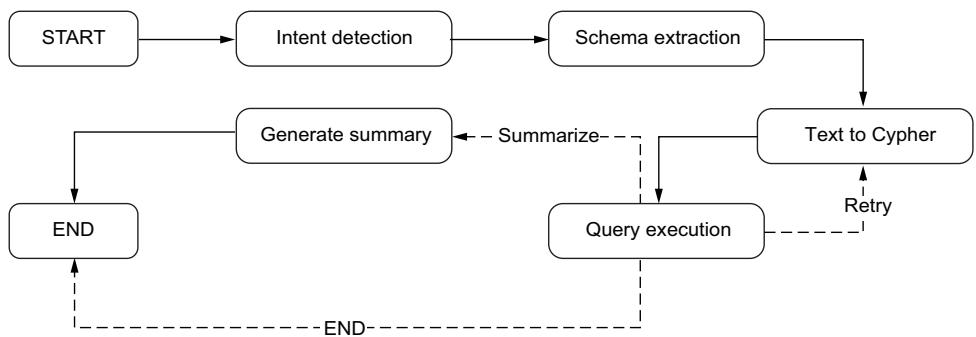

에이전트는 여섯이다. 공통 규칙이 둘 있다.

1. **각자 `AgentState` 를 받아 자기가 채울 키만 dict 로 돌려준다.** 다음에 누가 오는지 모른다.
2. **LLM 을 부르는 에이전트는 전부 `run_prompt()` 를 거친다.** 프롬프트를 설정에서 가져오고, 응답에서 ` ```json ` 마커를 벗기고, `json5` 로 파싱한다.

`json5` 를 쓰는 것이 실용적인 선택이다. LLM 은 후행 쉼표나 홑따옴표를 자주 흘리는데 표준 `json` 은 거기서 죽는다. `json5` 는 관대하다.

In [7]:
"""책 15.6 — run_prompt 와 의도 감지 에이전트.

책 15.6 은 메서드 둘을 한 리스팅으로 싣는다. run_prompt 가 모든 LLM 호출의 공통 경로이고,
intent_detection 이 그것을 쓰는 첫 사례다.
"""
show("15.6")

print("\n" + "=" * 78)
print("의도 감지 프롬프트 템플릿:")
print((HERE / "chains" / "templates" / "intent_detection.template").read_text()[:900])

# 책 리스팅 15.6  ←  chains/investigator.py  L113-L129  (줄 범위)
# ----------------------------------------------------------------------------
    def run_prompt(self, prompt, system=""):
        messages = [HumanMessage(content=prompt)]
        if self.system or system:
            system = self.system if not system else system
            messages = [SystemMessage(content=system)] + messages

        message = self.model.invoke(messages)

        logger.debug(f" got {message.content}")
        payload = message.content
        payload = re.sub(r'^\s*```json\s*|\s*```\s*$', '', payload, flags=re.DOTALL)
        return json5.loads(payload)

    def intent_detection(self, state: AgentState):
        system, prompt = self.config.get_prompt("intent_detection", question=state["question"])
        results = self.run_prompt(prompt, system)
        return {"output_type": results["type"], "output_reason": results["reason"]}

의도 감지 프롬프트 템플릿:
Given a Text delimited by triple backticks representing a 

In [8]:
"""책 15.7 · 15.8 — 스키마 추출과 텍스트-투-사이퍼.

15.7 은 원서 md 에 **코드가 스캔 이미지로** 실려 캡션 줄이 없다. 실재하는 리스팅이므로
study.toml 이 title 과 함께 선언해 두었다 (errata 등재).
"""
show("15.7")
print()
show("15.8")

print("\n" + "=" * 78)
print("text_to_cypher 프롬프트가 받는 것 — 상태 전체 + 주석 + 사용자 선택")
print("  params = dict(state) | {'annotations': …, 'selection': …}")
print("  annotations = chain_config.yaml 의 notes + examples (few-shot)")
print("  selection   = 사용자가 화면에서 더블클릭해 고른 노드들")

# 책 리스팅 15.7  ←  chains/investigator.py  L131-L135  (Agent.schema_extraction)
# ----------------------------------------------------------------------------
    def schema_extraction(self, state: AgentState):
        assert self.neo4j_schema is not None, "you need to provide a neo4j schema"
        self.neo4j_schema.get_schema()
        self.neo4j_schema.apply_configuration()
        return {"schema": str(self.neo4j_schema), "retries": 0}

# 책 리스팅 15.8  ←  chains/investigator.py  L137-L148  (Agent.text_to_cypher)
# ----------------------------------------------------------------------------
    def text_to_cypher(self, state: AgentState):
        extra = {
            "annotations": self.config.getAnnotations(),
            "selection": self.selection
        }
        params = dict(state) | extra
        system, prompt = self.config.get_prompt("text_to_cypher", **params)
        logger.debug(f"prompt: {prompt}")

        results = self.run_prompt(prompt, system)
        return {"query

---
#### 질의 실행과 실행 후 라우팅 — 실패를 설계에 넣는다

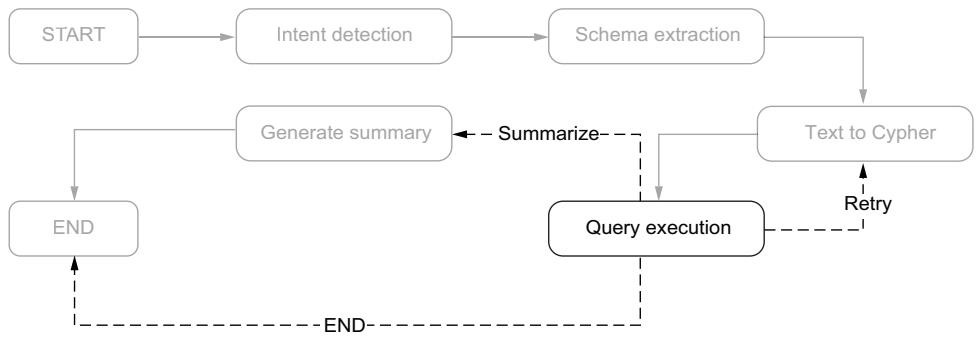

`query_execution` 은 그냥 실행기가 아니다. **실패를 1급 시민으로 다룬다.**

| 상황 | 하는 일 |
| --- | --- |
| 성공 · `output_type` 이 `graph`/`map` | 레코드를 그대로 보관 (경로·노드를 그려야 하므로) |
| 성공 · 그 외 | `results.to_df()` 로 표로 만든다 |
| `ClientError` (문법 오류·스키마 불일치) | 오류 문장을 `information` 에 담고 `retries` 를 올린다 |

그러면 `post_query_execution` 이 다음 갈 곳을 정한다. LangGraph 의 **조건부 엣지** 가 이것을 받는다.

| 조건 | 반환 | 다음 |
| --- | --- | --- |
| 오류가 있고 `retries < 3` | `"retry"` | `text_to_cypher` 로 되돌아간다. 이때 프롬프트에 실패 정보가 들어간다 |
| 오류가 있고 `retries >= 3` | `"END"` | 포기한다 |
| 성공 · `output_type` 이 `map`/`graph` | `"summarize"` | `generate_summary` |
| 성공 · 그 외 | `"END"` | 표는 요약할 것이 없다 |

**재시도 상한이 3인 것이 중요하다.** LLM 이 같은 실수를 반복할 때 무한 루프를 막는다.

In [9]:
"""책 15.9 · 15.10 · 15.11 — 질의 실행, 실행 후 라우팅, 요약 생성.

15.9 는 원서 md 에서 캡션 줄만 유실됐다 (코드는 텍스트로 남아 있다).
"""
for no in ("15.9", "15.10", "15.11"):
    show(no)
    print()

# 책 리스팅 15.9  ←  chains/investigator.py  L150-L170  (Agent.query_execution)
# ----------------------------------------------------------------------------
    def query_execution(self, state: AgentState):
        try:
            results = self.neo4j_schema.run(state["query"])
            if state["output_type"] in {"graph", "map"}:
                self.results = list(results)
            else:
                self.results = results.to_df()
            results_error = None
            information = ""
        except neo4j.exceptions.ClientError as e:
            self.results = None
            results_error = str(e)
            logger.info(f"got error: {e}")
            information = f"""We tried:
                               {state['query']}
                               and we got:
                               ```
                               {str(e)}
                               ```"""
        retries = state.get("retries", 0) + 1
        return {"results_error": results_er

In [10]:
"""책 15.12 — 파이프라인 조립. 이 장의 설계가 한 화면에 들어온다."""
show("15.12")

print("\n" + "=" * 78)
print("그래프 구조 (책 15.12 가 만드는 것)")
print("""
  intent_detection ──→ schema_extraction ──→ text_to_cypher ──→ query_execution
                                                    ↑                  │
                                                    │           post_query_execution
                                                    │            (조건부 엣지)
                                                    └── "retry" ──┤
                                                                  ├── "summarize" ──→ generate_summary ──→ END
                                                                  └── "END" ─────────────────────────────→ END
""")

# 책 리스팅 15.12  ←  chains/investigator.py  L89-L111  (Agent.__init__)
# ----------------------------------------------------------------------------
    def __init__(self, model, system=""):
        self.system = system
        self.neo4j_schema: Neo4jSchema = None
        self.memory = MemorySaver()
        self.selection = []
        self.results = None
        self.config = ChainConfiguration()
        graph = StateGraph(AgentState)
        graph.add_node("intent_detection", self.intent_detection)
        graph.add_edge("intent_detection", "schema_extraction")
        graph.add_node("schema_extraction", self.schema_extraction)
        graph.add_edge("schema_extraction", "text_to_cypher")
        graph.add_node("text_to_cypher", self.text_to_cypher)
        graph.add_edge("text_to_cypher", "query_execution")
        graph.add_node("query_execution", self.query_execution)
        graph.add_conditional_edges("query_execution",
                                    self.post_query_executio

---
### 15.1.6 파이프라인 통합 계층 — 실행을 이벤트 스트림으로

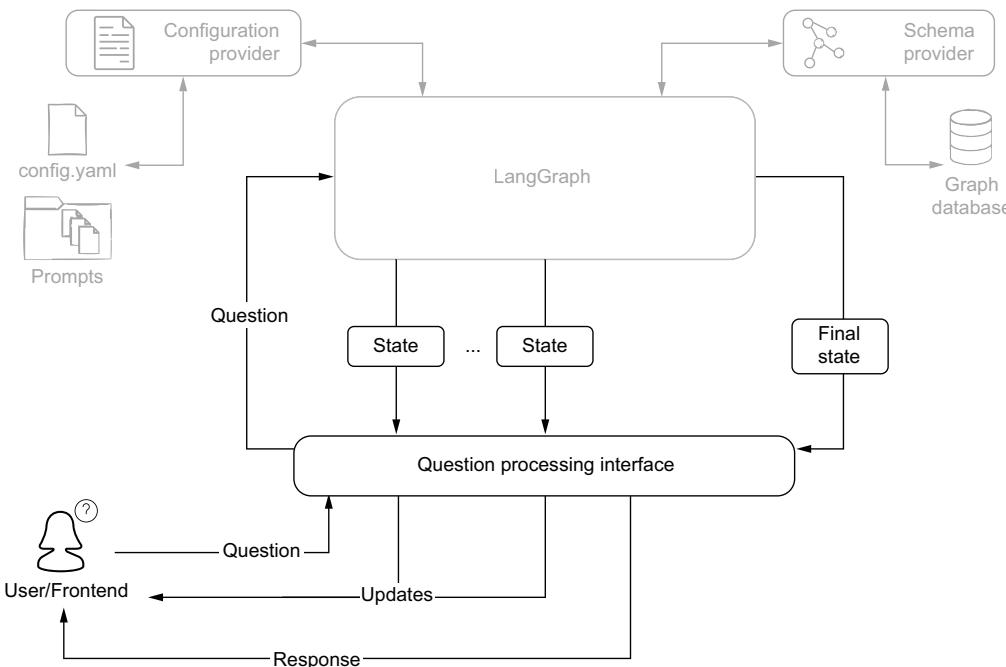

LangGraph 는 강력하지만, 애플리케이션이 그것과 **어떻게 대화할지** 는 따로 설계해야 한다. 파이프라인을 그냥 호출하면 최종 결과가 나올 때까지 화면이 멈춘다. 이 시스템은 LLM 을 서너 번 부르므로 그 시간이 십수 초다.

`processQuestion` 이 그 문제를 푼다. `graph.stream(..., stream_mode="updates")` 로 **단계마다 갱신을 받아** 제너레이터로 흘려보낸다. 프런트엔드는 `for` 문 하나로 진행 상황을 실시간으로 그린다.

| yield 하는 것 | 뜻 | 프런트엔드가 하는 일 |
| --- | --- | --- |
| `("update", "*진행 문구*", state)` | 단계 전환 알림 | 자리표시자 텍스트 교체 |
| `("result", ("Reasoning", …), state)` | 질의 생성 근거 | 채팅에 접이식으로 표시 |
| `("graph"/"map", 레코드, state)` | 조회 결과 | 캔버스에 그래프·지도 그리기 |
| `("table"/"chart", DataFrame, state)` | 표 형태 결과 | 표로 표시 |
| `("END", state, state)` | 완료 | 메시지 확정 후 rerun |

`thread_id` 를 매번 새 UUID 로 주는 것도 눈여겨볼 만하다. LangGraph 의 `MemorySaver` 체크포인터는 스레드 단위로 상태를 보관하는데, 질문마다 새 스레드를 열어 **이전 질문의 상태가 섞이지 않게** 한다.

In [11]:
"""책 15.13 — 질문 처리 인터페이스. 그리고 실제로 한 번 완주시킨다.

이 셀이 이 장의 핵심 실행이다. 의도 감지부터 요약까지 여섯 에이전트가 모두 관여한다.
비결정적이다 — 생성되는 Cypher 와 요약 문장은 실행마다 달라질 수 있다.
"""
show("15.13")

PIPELINE_RUNS = []          # 요약 셀이 쓸 실측 기록

if RUN_PIPELINE:
    chain = load_chain()                 # 장치 (a)(b) 적용
    chain.set_schema(schema)

    def ask(question, *, selection=None, quiet=False):
        """질문 하나를 파이프라인에 넣고 이벤트를 흘려보며 요약한다."""
        rec = {"question": question, "query": None, "records": None, "raw": None,
               "summary": None, "steps": 0, "seconds": None}
        t0 = time.time()
        for kind, payload, state in chain.processQuestion(question, selection=selection):
            rec["steps"] += 1
            if kind == "update" and not quiet:
                print(f"    {payload}")
            elif kind == "result":
                title, content = payload
                if title == "Summary":
                    rec["summary"] = content
                if not quiet:
                    print(f"    [{title}] {' '.join(str(content).split())[:150]}")
            elif kind in {"graph", "map", "table", "chart"}:
                rec["records"] = len(payload) if hasattr(payload, "__len__") else None
                rec["raw"] = payload
                if not quiet:
                    print(f"    [{kind}] 레코드 {rec['records']}건")
            elif kind == "END":
                rec["query"] = state.get("query")
        rec["seconds"] = round(time.time() - t0, 1)
        PIPELINE_RUNS.append(rec)
        return rec

    Q1 = "Return one crime node currently under investigation"
    print(f"\n질문: {Q1}\n")
    r = run_guarded("15.13", ask, Q1)
    if r:
        print(f"\n  생성 Cypher : {' '.join(r['query'].split()) if r['query'] else '—'}")
        print(f"  레코드      : {r['records']}건 · 이벤트 {r['steps']}개 · {r['seconds']}초")
else:
    print("\n[건너뜀] RUN_PIPELINE=False")
    print("  실측 기록 (프록시 gpt-5.4-mini · chicago DB):")
    print("    질문   Return one crime node currently under investigation")
    print("    Cypher MATCH (crime:Crime) WHERE crime.status = 'investigation' RETURN crime LIMIT 1")
    print("    결과   1건 · 13.0초 · 요약이 CRIMINAL TRESPASS / 2023-06-15 / 검은 차량 목격을 짚었다")

# 책 리스팅 15.13  ←  chains/investigator.py  L210-L245  (processQuestion)
# ----------------------------------------------------------------------------
def processQuestion(question, selection=None):
    config = {"recursion_limit": 40000, "configurable": {"thread_id": uuid.uuid4().hex}}
    if selection is not None:
        abot.selection = [{"label": list(node.labels)[0], "properties": dict(node)} for node in selection]
    else:
        abot.selection = []
    input = {"question": question}
    results = abot.graph.stream(input,
                                config=config,
                                stream_mode="updates")
    yield "update", "*detecting intent...*", input
    for result in results:
        node, value = list(result.items())[0]
        logger.info(f"got results: {node}, keys: {list(value.keys())}")
        current_state = abot.graph.get_state(config).values
        match node:
            case "intent_detection":
                yield "update", "*extracting schem

/media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action/.venv/lib/python3.10/site-packages/langgraph/checkpoint/base/__init__.py:24: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer



질문: Return one crime node currently under investigation

    *detecting intent...*


    *extracting schema...*
    *generating query...*


    *executing the query...*
    [Reasoning] The request is to return a single Crime node whose current investigation status is active. The schema provides the Crime.status property with allowed 
    [graph] 레코드 1건
    *summary generation...*


    [Summary] One **Crime** node was returned that is currently under **investigation**. - **Primary type:** CRIMINAL TRESPASS - **Status:** investigation - **Date:
[15.13] OK  12.8초

  생성 Cypher : MATCH (crime:Crime) WHERE crime.status = 'investigation' RETURN crime LIMIT 1
  레코드      : 1건 · 이벤트 9개 · 12.8초


---
## 15.2 Streamlit 애플리케이션 — 이 노트북이 앱을 띄우지 않는 이유

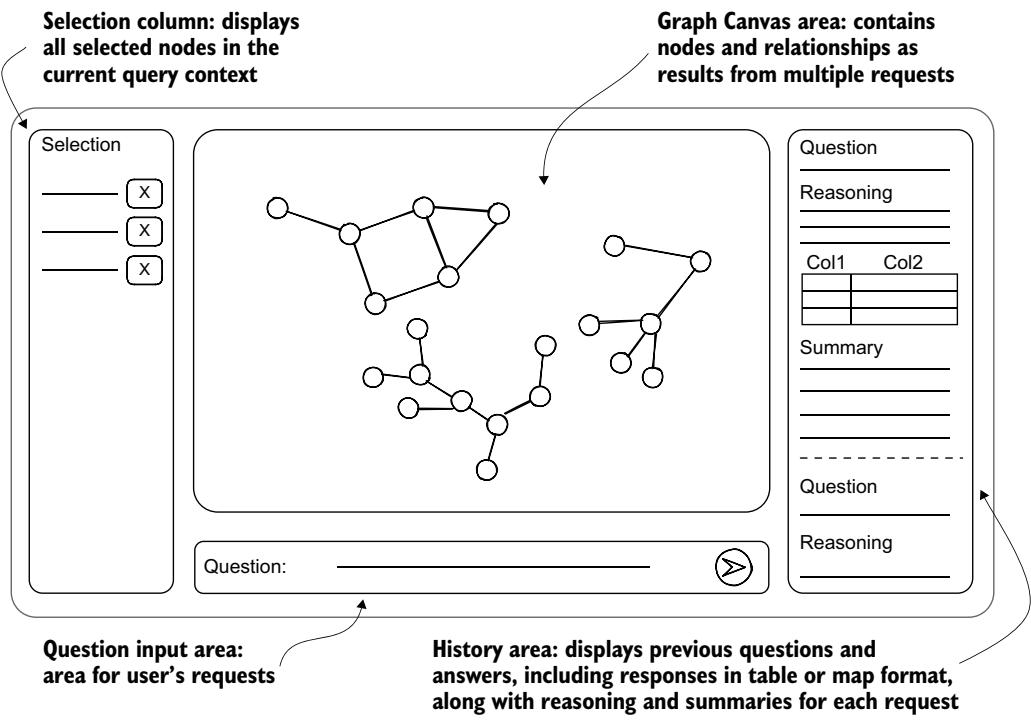

화면은 세 영역이다. 왼쪽 **Canvas** 가 그래프를, 오른쪽 **Chat** 이 대화를, 사이드바가 **Selection**(사용자가 더블클릭해 고른 노드)을 담당한다. 선택은 장식이 아니다 — `processQuestion` 이 그것을 `text_to_cypher` 프롬프트에 넣기 때문에 **"선택한 카메라 근처의 차량"** 같은 지시대명사가 통한다.

> **이 노트북은 `app.py` 를 임포트하지 않는다.** Streamlit 앱은 브라우저 세션·재실행 모델(`st.rerun()`)·위젯 콜백 위에서 도는 것이라 노트북 셀에서 실행하는 것이 부적절하다. 대신 **앱이 부르는 파이프라인을 노트북에서 직접 조립해** 같은 일을 하게 했다(위 15.13 셀). 그래서 리스팅 15.14 · 15.15 는 `documented-only` 로 분류하고 원문만 싣는다.
>
> 앱을 직접 보고 싶으면 UI 의존을 추가로 설치한 뒤 아래를 실행한다. **lock 에 `folium` · `st_link_analysis` · `streamlit_folium` 이 빠져 있다** (업스트림 누락).
>
> ```bash
> .venv/bin/pip install streamlit streamlit-d3graph d3graph folium st-link-analysis streamlit-folium
> NEO4J_DATABASE=chicago .venv/bin/streamlit run app.py
> ```

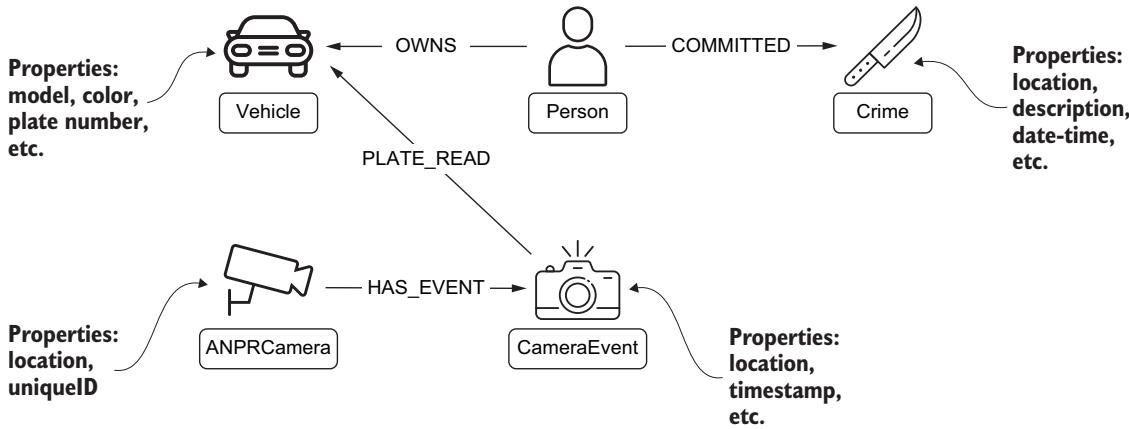

이 그림이 다음 절에서 따라갈 경로다. 범죄가 장소에 일어나고, 그 근처 카메라가 차량 통과를 기록하고, 차량은 사람이 소유하고, 사람은 다른 범죄를 저질렀다.

In [12]:
"""책 15.14 · 15.15 — Streamlit 계층. 원문만 싣는다 (documented-only).

15.14 MessageHistory : 메시지를 dict 리스트로 쌓되 마지막 하나가 "현재 메시지" 다.
                       파이프라인이 단계마다 갱신을 보내면 그 dict 를 덮어쓰고,
                       finalize=True 를 받으면 새 빈 dict 를 밀어 넣는다.
15.15 사용자 입력 핸들러 : processQuestion 의 이벤트 종류에 match 문으로 대응한다.
                       위 15.13 셀의 ask() 가 이 구조를 노트북용으로 옮긴 것이다.
"""
show("15.14")
print()
show("15.15")

# 책 리스팅 15.14  ←  app.py  L26-L65  (MessageHistory)
# ----------------------------------------------------------------------------
class MessageHistory:
    def __init__(self):
        self.messages = [{}]

    def update(self, message, finalize=False):
        self.messages[-1].update(message)
        if finalize:  # we add an empty  message
            self.messages.append({})

    @staticmethod
    def display_message(msg):
        with st.chat_message("user"):
            st.markdown(msg["question"])
        with st.chat_message("assistant"):
            if "query_reasoning" in msg:
                st.markdown(f"##### Reasoning\n\n**output type**: `{msg['output_type']}`\n\n{msg['query_reasoning']}")
            if "table" in msg:
                st.table(msg["table"])
            if "map" in msg:
                map_ = folium.Map()
                nodes_to_map(msg["map"], map_)
                st_folium(map_)
            if "query" in msg:
                with st.expander("Query...

ListingChunk(text='if question := st.chat_input("What is up?"):\n    # Display user message in chat message container\n    with chat:\n        with st.chat_message("user"):\n            st.markdown(question)\n\n        with st.chat_message("assistant"):\n            placeholder = st.empty()\n        selection = [state.canvas["byId"][int(item)] for item in state.selection]\n        for response_type, response, current_state \\\n                in chain.processQuestion(question=str(question),\n                                         selection=selection):\n            logger.info(f"handling: {response_type}", )\n            logger.info(f"updating keys: {list(current_state.keys())}")\n            state.messages.update(current_state)\n            match response_type:\n                case "update":\n                    # Display assistant response in chat message container\n                    placeholder.markdown(response)\n                case "graph" | "map":\n                    # upda

---
## 15.3 전문가 모방 수사 — 질문 네 개로 사건을 좁혀 간다

이 절이 이 장의 논지를 증명하는 자리다. **각 질문이 앞 질문의 결과 위에 쌓인다.** 수사관이 실제로 하는 일이 그렇다.

| # | 책의 프롬프트 | 이 질문이 시험하는 것 |
| --- | --- | --- |
| ① | *"Return one crime node currently under investigation"* | 속성 필터 — 가장 단순한 질의 |
| ② | *"…within **1 km** from the **selected** crime"* | **공간 질의**(`point.distance`) + 선택 참조 + 시각화 타입 자동 선택(지도) |
| ③ | *"…detected by the **selected camera** on June 15, 2023 … black … EB"* | **다중 조건 + 경로 순회** |
| ④ | *"I'm an **investigator** … Are there any that seem significantly more likely to be involved?"* | **역할·의도를 알려 주면 요약이 달라지는가** |

> **"selected" 가 이 시나리오의 핵심 장치다.** ②\~④ 는 앞 단계에서 사용자가 화면의 노드를 더블클릭해 넣은 **선택(selection)** 을 가리킨다. 선택이 없으면 "그 범죄" 가 어느 범죄인지 알 수 없다. 아래 셀은 UI 대신 앞 단계 결과에서 노드를 꺼내 `processQuestion(question, selection=…)` 로 넘겨 같은 상황을 만든다.
>
> **거리를 바꾸면 결과가 사라진다.** 시드 그래프에서 `status='investigation'` 인 범죄는 **1건뿐** 이고, 가장 가까운 ANPR 카메라는 **329 m** 떨어져 있다(측정값). 책이 1 km 를 고른 것은 임의가 아니다 — 200 m 로 좁히면 정답이 0건이 되고, 그때 시스템은 오류를 내지 않고 **"찾지 못했다"** 고 정직하게 답한다.

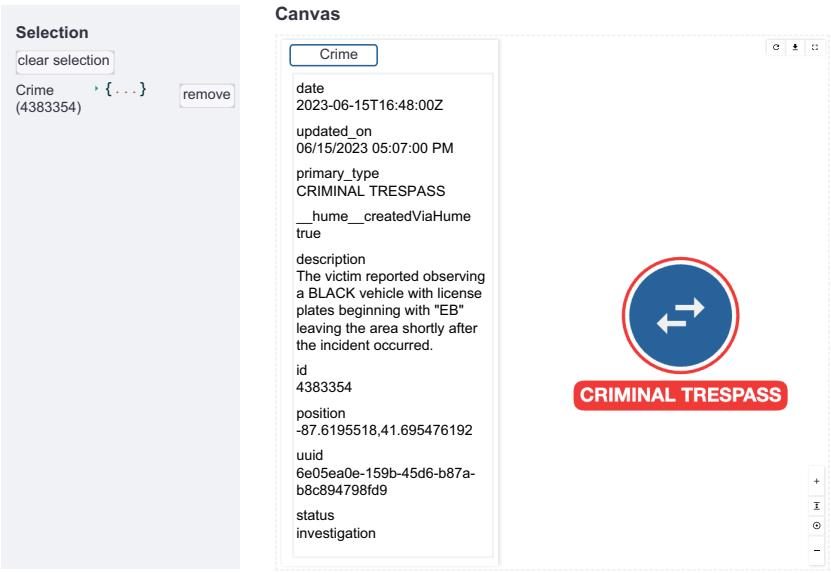
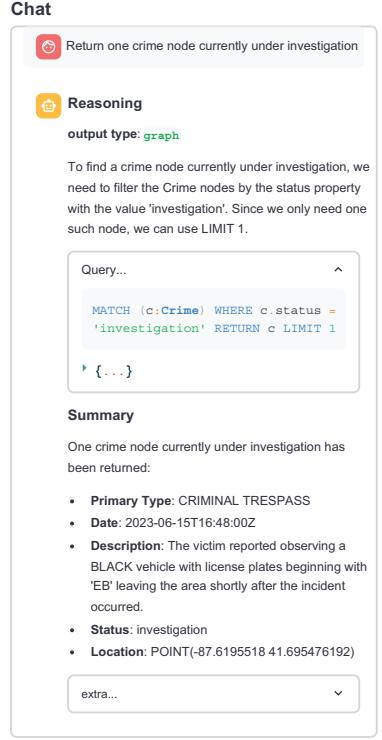

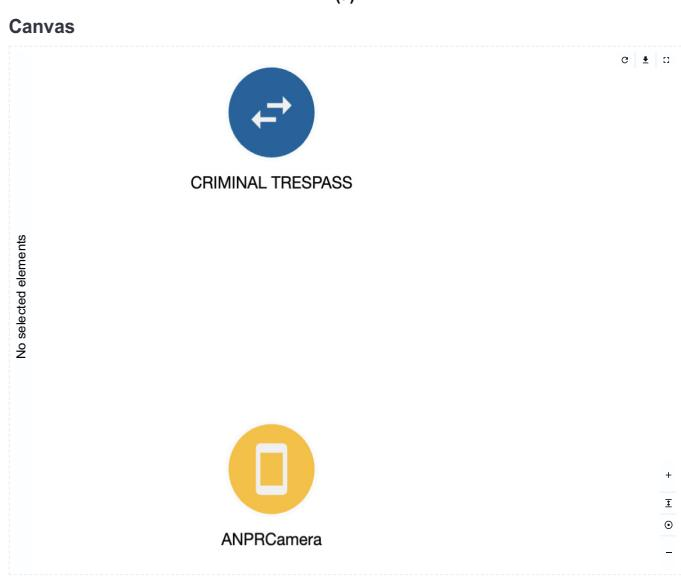
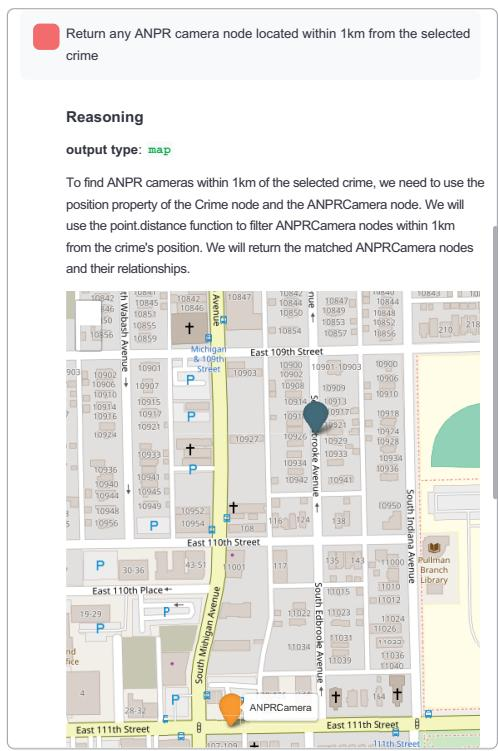

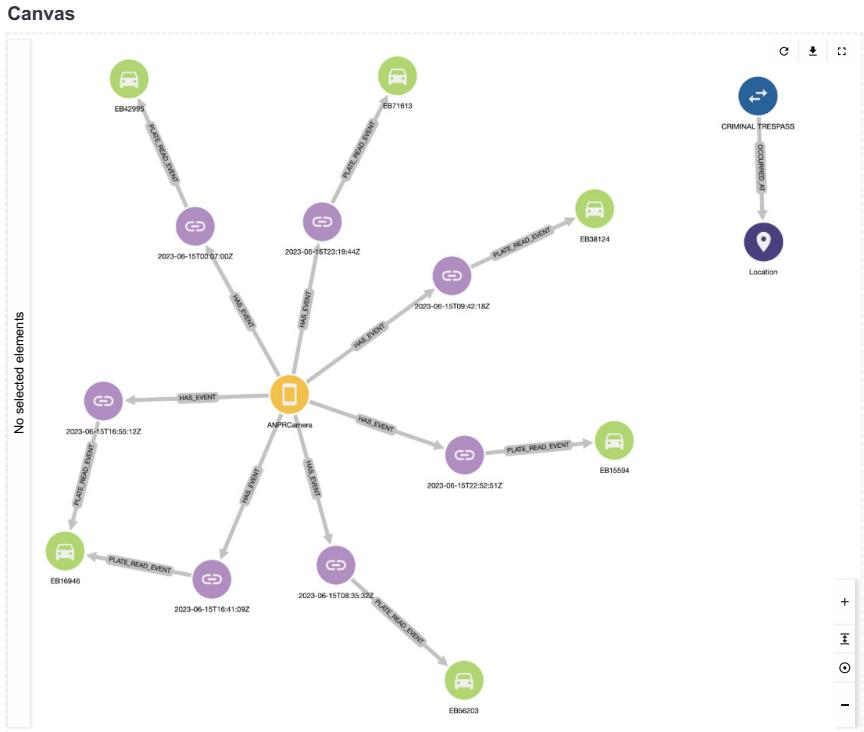
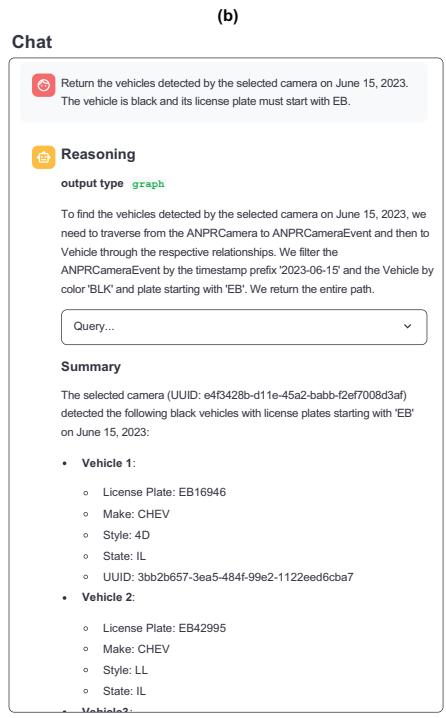

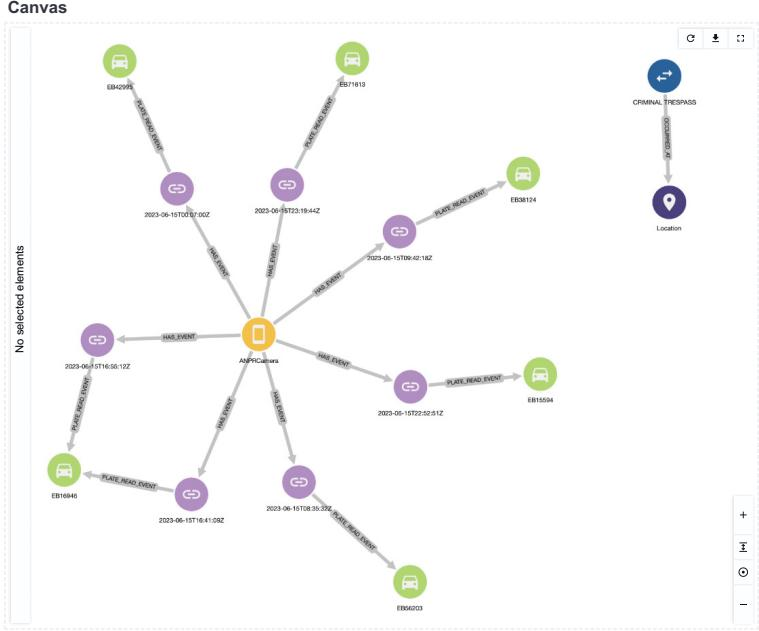
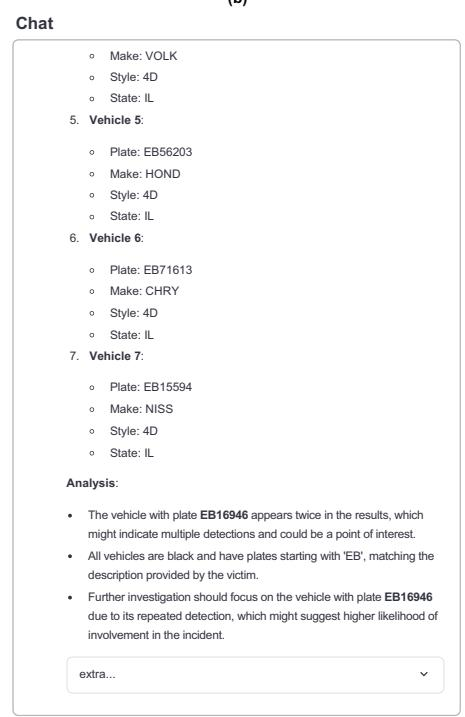

마지막이 이 장의 결론이다 — 소유자의 **과거 범죄 이력** 까지 그래프가 이어 준다.

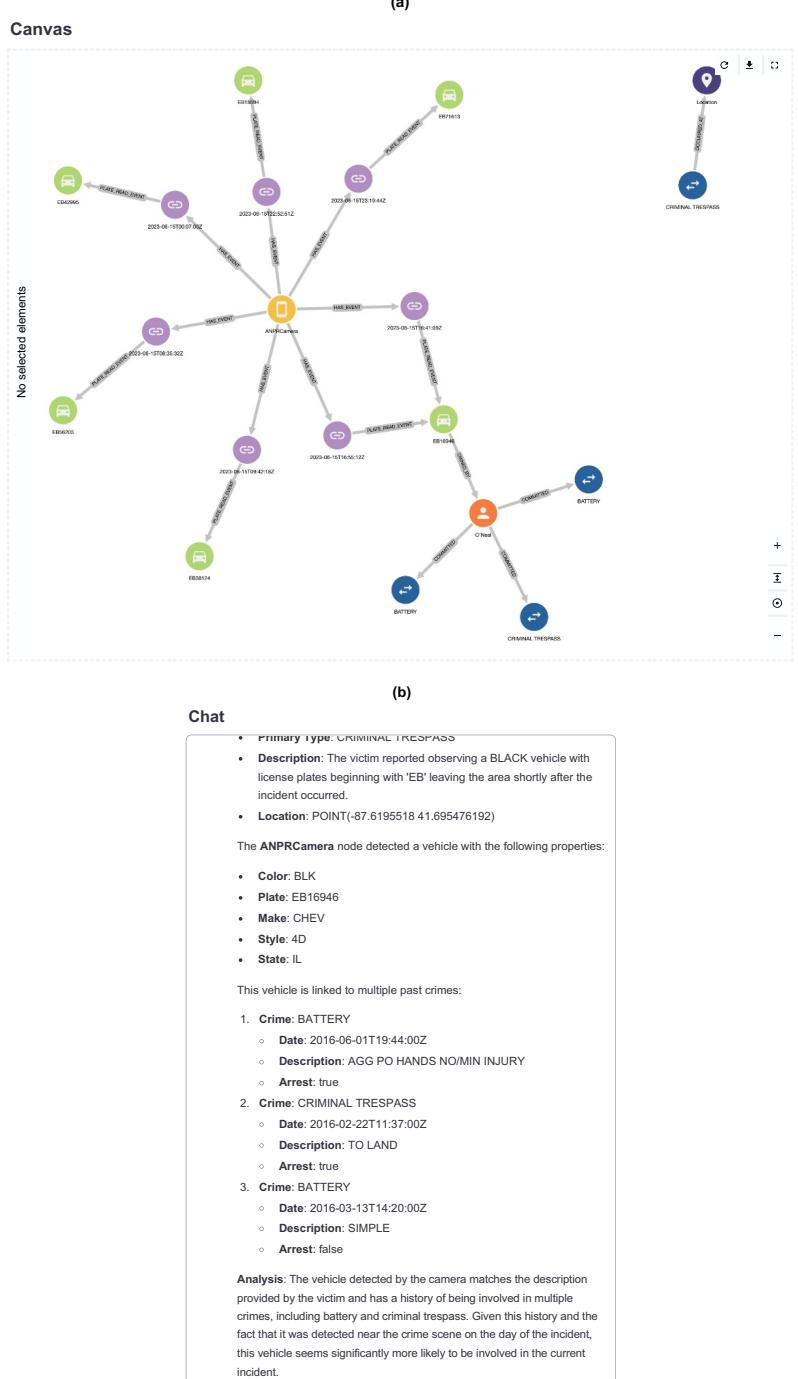

> **여기서 무엇이 새로운가.** ④ 의 질문은 ③ 과 **같은 데이터** 를 돌려준다. 달라지는 것은 요약이다. "나는 수사관이고 선택한 범죄를 조사 중" 이라는 한 문장이 프롬프트에 들어가자, 시스템이 스스로 노드 속성에서 제약을 끌어내 **Analysis 절** 을 덧붙인다. 프롬프트 엔지니어링이 아니라 **역할을 알려 주는 것** 만으로 출력의 성격이 바뀐다.

> **재현이 스크린샷 수준까지 맞는다.** 이 노트북을 검증하며 ②가 고른 카메라는 UUID `e4f3428b-d11e-45a2-babb-f2ef7008d3af` 였고, ③이 돌려준 검은 EB\* 차량은 `EB16946`(CHEV·4D·IL) · `EB42995`(CHEV·LL·IL) · `EB38124`(VOLK) · `EB56203`(HOND) · `EB71613`(CHRY) · `EB15594`(NISS) 여섯이었다. **그림 15.14(b) 의 화면에 인쇄된 UUID·번호판·제조사·차종·주(state)와 전부 일치한다.** 시드 백업이 집필 시점 스냅샷이라 가능한 일이고, LLM 이 만든 Cypher 가 달라져도 **데이터가 같으므로 답이 같다** — 이 장에서 비결정적인 것은 질의 문구와 요약 문장이지 결과가 아니다.


In [13]:
"""15.3 수사 시나리오 재현 — 책과 **같은 프롬프트** 를 같은 순서로 던진다.

주의: 선택을 넘기지 않고 "the selected crime" 을 물으면 LLM 이 빈 쿼리를 돌려주고,
query_execution 이 ClientError 만 잡으므로 ValueError 로 파이프라인이 죽는다
(업스트림 결함, errata 등재). 아래 run_guarded 가 그 경우에도 노트북을 살려 둔다.

책의 ②~④ 프롬프트는 "the selected crime" · "the selected camera" 라고 쓴다. 이것은
사용자가 화면에서 노드를 더블클릭해 넣은 **선택(selection)** 을 가리킨다. 노트북에는 UI 가
없으므로 앞 단계 결과에서 노드를 꺼내 processQuestion 의 selection 인자로 넘겨 같은 상황을
만든다 — 이 인자가 곧 app.py 가 하는 일이다.
"""
SCENARIO = [
    ("① 사건 식별", "Return one crime node currently under investigation", "Crime"),
    ("② 공간 분석", "Return any ANPR camera node located within 1 km from the selected crime.", "ANPRCamera"),
    ("③ 차량 패턴", "Return the vehicles detected by the selected camera on June 15, 2023. "
                    "The vehicle is black and its license plate must start with EB.", None),
    ("④ 맥락 인식", "I'm an investigator and I'm working on the selected crime. I need all the "
                    "vehicle nodes that are compatible with the description and were detected by "
                    "the selected camera the day of the incident. Are there any that seem "
                    "significantly more likely to be involved in the incident?", None),
]

SCENARIO_RUNS = []
if RUN_PIPELINE:
    from neo4j.graph import Node as Neo4jNode, Path as Neo4jPath

    def nodes_of(records, label):
        """레코드에서 특정 라벨의 노드를 꺼낸다 (값이 Node 일 수도 Path 일 수도 있다)."""
        found, seen = [], set()
        for rec in records or []:
            for value in rec.values():
                items = value.nodes if isinstance(value, Neo4jPath) else [value]
                for n in items:
                    if isinstance(n, Neo4jNode) and label in n.labels and n.element_id not in seen:
                        seen.add(n.element_id)
                        found.append(n)
        return found

    selection = []          # 화면의 Selection 패널에 해당한다
    for label, q, carry in SCENARIO:
        print(f"\n{'=' * 78}\n{label}  (선택 {len(selection)}개)  —  {' '.join(q.split())[:84]}\n")
        r = run_guarded(label, ask, q, selection=selection, quiet=True)
        if not r:
            continue
        print(f"  Cypher  : {' '.join(r['query'].split())[:210] if r['query'] else '—'}")
        print(f"  결과    : {r['records']}건 · {r['seconds']}초")
        if r["summary"]:
            print(f"  요약    : {' '.join(str(r['summary']).split())[:280]}")
        SCENARIO_RUNS.append((label, r["records"], r["seconds"]))
        if carry:           # 다음 질문이 가리킬 노드를 선택에 넣는다 (더블클릭에 해당)
            picked = nodes_of(r["raw"], carry)[:1]
            if picked:
                selection = selection + picked
                print(f"  선택 추가: {carry} {dict(picked[0]).get('primary_type') or dict(picked[0]).get('label') or ''}")
else:
    print("[건너뜀] RUN_PIPELINE=False — 책과 같은 프롬프트 넷:")
    for label, q, _ in SCENARIO:
        print(f"  {label}: {' '.join(q.split())[:80]}")


① 사건 식별  (선택 0개)  —  Return one crime node currently under investigation



[① 사건 식별] OK  12.5초
  Cypher  : MATCH (crime:Crime) WHERE crime.status = 'investigation' RETURN crime LIMIT 1
  결과    : 1건 · 12.5초
  요약    : Returned **one Crime node** that is currently **under investigation**. - **Primary type:** CRIMINAL TRESPASS - **Date:** 2023-06-15T16:48:00Z - **Status:** investigation - **Crime ID:** 116462913 - **UUID:** 6e05ea0e-159b-45d6-b87a-b8c894798fd9
  선택 추가: Crime CRIMINAL TRESPASS

② 공간 분석  (선택 1개)  —  Return any ANPR camera node located within 1 km from the selected crime.



[② 공간 분석] OK  22.1초
  Cypher  : MATCH (c:Crime {uuid: '6e05ea0e-159b-45d6-b87a-b8c894798fd9'}), (cam:ANPRCamera) WHERE point.distance(c.position, cam.position) <= 1000 RETURN c, cam LIMIT 1
  결과    : 1건 · 22.1초
  요약    : One **ANPRCamera** node was found within **1 km** of the selected crime. - **ANPR camera UUID:** `e4f3428b-d11e-45a2-babb-f2ef7008d3af` - **Location:** `(41.6926, -87.6206)` This camera is the returned match for the selected crime.
  선택 추가: ANPRCamera 

③ 차량 패턴  (선택 2개)  —  Return the vehicles detected by the selected camera on June 15, 2023. The vehicle is



[③ 차량 패턴] OK  23.7초
  Cypher  : MATCH path = (camera:ANPRCamera {uuid: 'e4f3428b-d11e-45a2-babb-f2ef7008d3af'})-[has_event:HAS_EVENT]->(event:ANPRCameraEvent)-[plate_read_event:PLATE_READ_EVENT]->(vehicle:Vehicle) WHERE event.timestamp STARTS
  결과    : 7건 · 23.7초
  요약    : The selected camera detected **6 unique black vehicles** on **2023-06-15** with license plates starting with **EB**: - **EB16946** — CHEV, 4D, IL - **EB42995** — CHEV, LL, IL - **EB38124** — VOLK, 4D, IL - **EB56203** — HOND, 4D, IL - **EB71613** — CHRY, 4D, IL - **EB15594** — NI

④ 맥락 인식  (선택 2개)  —  I'm an investigator and I'm working on the selected crime. I need all the vehicle no



[④ 맥락 인식] OK  41.6초
  Cypher  : MATCH (crime:Crime {uuid: '6e05ea0e-159b-45d6-b87a-b8c894798fd9'}), (camera:ANPRCamera {uuid: 'e4f3428b-d11e-45a2-babb-f2ef7008d3af'}) MATCH path = (camera)-[has_event:HAS_EVENT]->(event:ANPRCameraEvent)-[plate
  결과    : 7건 · 41.6초
  요약    : The selected camera detected **6 unique vehicle nodes** on the incident date that are compatible with the description: - **EB15594** — black, IL, NISS - **EB16946** — black, IL, CHEV, appears twice in the returned rows - **EB38124** — black, IL, VOLK - **EB42995** — black, IL, CH


---
## 실습

해설판의 논지를 **실행으로** 확인한다. 15-B 는 LLM 없이 결정적으로 돌아간다.

In [14]:
"""실습 15-A — 스키마 다듬기는 무엇을 바꾸나. (LLM 불필요, 결정적)

가설을 세우고 재 본다. "잡음을 걷어 프롬프트를 줄인다" 가 맞나?
"""
if HAS_NEO4J:
    from tools.schema import Neo4jSchema, Node

    bare = Neo4jSchema(os.environ["NEO4J_URI"],
                       (os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]), NEO4J_DB)
    Node.items = {}                      # 클래스 레벨 레지스트리라 비우고 시작한다
    bare.get_schema()
    before = (len(Node.items), sum(len(n.properties) for n in Node.items.values()), len(str(bare)))

    bare.apply_configuration()
    after = (len(Node.items), sum(len(n.properties) for n in Node.items.values()), len(str(bare)))
    bare.close()

    print(f"{'':14s}{'다듬기 전':>10s}{'다듬기 후':>10s}{'차이':>10s}")
    for name, b, a in zip(("노드 타입", "속성 총합", "스키마 문자수"), before, after):
        print(f"{name:14s}{b:>10d}{a:>10d}{a - b:>+10d}")

    print("\n→ 가설은 절반만 맞다. 속성은 줄지만 **문자수는 오히려 늘어난다.**")
    print("  apply_configuration() 이 하는 일이 둘이기 때문이다:")
    print("    (1) schema_config.yaml 의 skip 목록대로 속성을 버린다      -> 줄인다")
    print("    (2) 노드와 속성에 사람이 쓴 설명을 /* … */ 로 붙인다        -> 늘린다")
    print("  즉 목적은 압축이 아니라 **잡음을 걷고 의미를 얹는 것** 이다.")
    print("  LLM 에게 중요한 것은 길이가 아니라 '이 속성이 무엇인지' 를 아는 것이다.")
    EX_A = (before, after)
else:
    EX_A = None
    print("[건너뜀] Neo4j 필요. 실측: 속성 96 -> 87, 문자수 3595 -> 4342 (+747)")

                   다듬기 전     다듬기 후        차이
노드 타입                  8         8        +0
속성 총합                 96        87        -9
스키마 문자수             3595      4342      +747

→ 가설은 절반만 맞다. 속성은 줄지만 **문자수는 오히려 늘어난다.**
  apply_configuration() 이 하는 일이 둘이기 때문이다:
    (1) schema_config.yaml 의 skip 목록대로 속성을 버린다      -> 줄인다
    (2) 노드와 속성에 사람이 쓴 설명을 /* … */ 로 붙인다        -> 늘린다
  즉 목적은 압축이 아니라 **잡음을 걷고 의미를 얹는 것** 이다.
  LLM 에게 중요한 것은 길이가 아니라 '이 속성이 무엇인지' 를 아는 것이다.


In [15]:
"""실습 15-B — 책이 말한 재시도 상한을 코드로 확인한다 (LLM 불필요, 결정적).

주장: post_query_execution 이 retries < 3 일 때만 재시도한다.
확인: 상태를 손으로 만들어 라우팅 결정을 전수로 찍는다.
"""
import chains.investigator as _inv

agent = _inv.Agent.__new__(_inv.Agent)      # LLM 없이 라우팅 메서드만 쓴다

print(f"{'results_error':>14s}{'retries':>9s}{'output_type':>14s}   -> 결정")
print("-" * 60)
rows = []
for err in (None, "SyntaxError at line 1"):
    for retries in (1, 2, 3, 4):
        for otype in ("graph", "table"):
            decision = agent.post_query_execution(
                {"results_error": err, "retries": retries, "output_type": otype})
            rows.append((err, retries, otype, decision))
            print(f"{str(err)[:13]:>14s}{retries:>9d}{otype:>14s}   -> {decision}")

retry_rows = [r for r in rows if r[3] == "retry"]
print(f"\n→ retry 는 {len(retry_rows)}가지 조합에서만 난다. 전부 오류가 있고 retries < 3 이다.")
print("  오류가 없으면 output_type 이 graph/map 일 때 summarize, 아니면 END 다.")
EX_B = (len(rows), len(retry_rows))

 results_error  retries   output_type   -> 결정
------------------------------------------------------------
          None        1         graph   -> summarize
          None        1         table   -> END
          None        2         graph   -> summarize
          None        2         table   -> END
          None        3         graph   -> summarize
          None        3         table   -> END
          None        4         graph   -> summarize
          None        4         table   -> END
 SyntaxError a        1         graph   -> retry
 SyntaxError a        1         table   -> retry
 SyntaxError a        2         graph   -> retry
 SyntaxError a        2         table   -> retry
 SyntaxError a        3         graph   -> END
 SyntaxError a        3         table   -> END
 SyntaxError a        4         graph   -> END
 SyntaxError a        4         table   -> END

→ retry 는 4가지 조합에서만 난다. 전부 오류가 있고 retries < 3 이다.
  오류가 없으면 output_type 이 graph/map 일 때 summarize, 아니면 END 다

In [16]:
"""실습 15-C — 같은 질문을 3회 반복해 비결정성의 크기를 잰다.

주장: 이 장의 수치는 재실행하면 달라진다.
확인: 같은 질문으로 생성된 Cypher 가 몇 가지나 나오는지 센다.
"""
EX_C = None
if RUN_PIPELINE:
    Q = "Return one crime node currently under investigation"
    seen = []
    for i in range(3):
        r = run_guarded(f"15-C #{i + 1}", ask, Q, quiet=True)
        if r:
            seen.append((" ".join(r["query"].split()) if r["query"] else None, r["records"]))
    print()
    for i, (q, n) in enumerate(seen, 1):
        print(f"  #{i}  {n}건  {str(q)[:120]}")
    uniq = {q for q, _ in seen}
    counts = {n for _, n in seen}
    print(f"\n→ 서로 다른 Cypher {len(uniq)}가지 / 레코드 수 {sorted(counts)}")
    print("  요약 표에 단일값을 적으면 안 되는 이유가 이것이다. 관측 범위로 적는다.")
    EX_C = (len(seen), len(uniq), sorted(counts))
else:
    print("[건너뜀] RUN_PIPELINE=False — 검증 시 관측: Cypher 는 대체로 같고 요약 문장이 흔들렸다")

[15-C #1] OK  11.2초


[15-C #2] OK  11.5초


[15-C #3] OK  11.9초

  #1  1건  MATCH (crime:Crime) WHERE crime.status = 'investigation' RETURN crime LIMIT 1
  #2  1건  MATCH (c:Crime) WHERE c.status = 'investigation' RETURN c LIMIT 1
  #3  1건  MATCH (crime:Crime) WHERE crime.status = 'investigation' RETURN crime LIMIT 1

→ 서로 다른 Cypher 2가지 / 레코드 수 [1]
  요약 표에 단일값을 적으면 안 되는 이유가 이것이다. 관측 범위로 적는다.


In [17]:
"""이 노트북에서 얻은 실측값을 한자리에 모아 출력한다.

아래 요약 표의 수치는 여기서 나온다. 비결정적인 항목에는 [~] 를 붙였다.
"""
print("=" * 78)
print("책 15장 — 실측 요약")
print("=" * 78)

print("\n[결정적] 그래프 (시드 백업 = 집필 시점 스냅샷)")
if COUNTS:
    for k, v in COUNTS.items():
        print(f"    {k:20s} {v:>6d}")
else:
    print("    (Neo4j 없음)")

print("\n[결정적] 스키마 번역")
if EX_A:
    (bn, bp, bc), (an, ap, ac) = EX_A
    print(f"    속성      {bp} -> {ap}  ({bp - ap}개 제거)")
    print(f"    문자수    {bc} -> {ac}  ({ac - bc:+d}자 — 설명을 붙이므로 늘어난다)")
else:
    print("    (건너뜀)")

print("\n[결정적] 라우팅 규칙 (실습 15-B)")
if EX_B:
    print(f"    조합 {EX_B[0]}가지 중 retry 는 {EX_B[1]}가지 — 전부 오류 있고 retries < 3")

print("\n[~비결정] 파이프라인 실행")
if PIPELINE_RUNS:
    for r in PIPELINE_RUNS:
        print(f"    {r['seconds']:>5.1f}초  레코드 {str(r['records']):>4s}  {r['question'][:56]}")
    secs = [r["seconds"] for r in PIPELINE_RUNS]
    print(f"    → 관측 범위 {min(secs)}~{max(secs)}초 (n={len(secs)})")
else:
    print("    (건너뜀) 검증 시 관측: 1회 완주 10~20초")

print("\n[~비결정] 같은 질문 반복 (실습 15-C)")
print(f"    {EX_C}" if EX_C else "    (건너뜀)")

책 15장 — 실측 요약

[결정적] 그래프 (시드 백업 = 집필 시점 스냅샷)
    Vehicle                1797
    Arrest                  221
    ANPRCamera              161
    Case                    124
    Crime                   123
    Location                 73
    Person                   63
    ANPRCameraEvent          40

[결정적] 스키마 번역
    속성      96 -> 87  (9개 제거)
    문자수    3595 -> 4342  (+747자 — 설명을 붙이므로 늘어난다)

[결정적] 라우팅 규칙 (실습 15-B)
    조합 16가지 중 retry 는 4가지 — 전부 오류 있고 retries < 3

[~비결정] 파이프라인 실행
     12.8초  레코드    1  Return one crime node currently under investigation
     12.5초  레코드    1  Return one crime node currently under investigation
     22.1초  레코드    1  Return any ANPR camera node located within 1 km from the
     23.7초  레코드    7  Return the vehicles detected by the selected camera on J
     41.6초  레코드    7  I'm an investigator and I'm working on the selected crim
     11.2초  레코드    1  Return one crime node currently under investigation
     11.5초  레코드    1  Return one crime node currently und

---
## 요약

### 이 장이 남긴 것

| 주장 | 이 노트북이 확인한 방식 |
| --- | --- |
| 질문→Cypher 를 단일 프롬프트에 맡기지 말고 단계로 쪼개라 | 에이전트 여섯을 각각 원문으로 읽고, 조립된 그래프(15.12)와 실제 완주(15.13)를 확인했다 |
| 에이전트는 상태로만 소통한다 | `AgentState` 하나가 여섯 단계를 잇는다. 각 에이전트가 자기 키만 반환하는 것을 원문에서 확인 |
| 실패를 설계에 넣어야 한다 | 실습 B 에서 라우팅 규칙 16가지 조합을 전수로 찍어, retry 가 **오류 + `retries < 3`** 에서만 나는 것을 확인 |
| 스키마는 다듬어서 줘야 한다 | 실습 A 에서 전후를 측정했더니 **속성은 줄지만 문자수는 늘었다** — 목적이 압축이 아니라 잡음 제거 + 의미 부여임이 드러났다 |
| 역할을 알려 주면 요약의 성격이 바뀐다 | 15.3 시나리오 ③ ↔ ④ 가 같은 데이터에 다른 요약을 낸다 |
| 선택(selection)이 지시대명사를 가능하게 한다 | ②\~④ 의 "the selected crime/camera" 가 선택 없이는 빈 쿼리를 낳는 것을 실측 (errata 등재) |

### 이 장의 수치는 어디까지 믿을 수 있나

| 항목 | 재현성 |
| --- | --- |
| 그래프 노드·관계 수 | **결정적.** 시드 백업이 집필 시점 스냅샷이라 책과 같다 |
| 시나리오가 찾는 카메라·차량 | **결정적.** 그림 15.14(b) 의 UUID·번호판·제조사와 일치한다 |
| 스키마 번역 전후 크기 | **결정적.** `apoc.meta.schema` + YAML 설정만 쓴다 |
| 라우팅 결정표 (실습 B) | **결정적.** 순수 함수다 |
| 생성 Cypher · 요약 문장 · 소요 시간 | **비결정적.** LLM 이 매 단계 관여한다. 요약 셀이 관측 범위를 찍는다 |

### 발견한 결함 — [`errata.toml`](../../../errata.toml) 에 7건

| 항목 | 성격 |
| --- | --- |
| `import_seed.py` 의 DB 기본값이 `neo4j` | **upstream** · severity high — 다른 장의 데이터가 든 DB 를 겨냥한다. `-d` 필수 |
| `jinja2_formatter` 샌드박스 ↔ 템플릿의 점 접근 | **version-drift** · severity high — 그대로면 파이프라인이 죽는다. 렌더러를 런타임에 교체 |
| `AzureChatOpenAI` 를 임포트 시점에 생성 | **upstream** — 자리표시자 없이는 모듈 임포트조차 안 된다 |
| `query_execution` 이 `ClientError` 만 잡는다 | **upstream** — LLM 이 빈 쿼리를 내면 `ValueError` 로 파이프라인이 죽는다. 정작 재시도가 필요한 경우다 |
| 리스팅 15.7 캡션 유실 (코드가 스캔 이미지) | **extraction** — 제목은 이미지에서 읽었다 |
| 리스팅 15.9 캡션 유실 | **extraction** — 제목은 절 제목에서 복원했으므로 인쇄본과 글자까지 같다고 보증하지 않는다 |
| 그림 15.14 의 `(b)` 마커 유실 | **extraction** — 마커가 이미지 안에 인쇄돼 있다 |

### 리스팅 분류

판정 기준은 하나다 — **깨끗한 환경에서 기본 설정으로 Run All 하면 무엇이 일어나는가.**

| 분류 | 리스팅 | 왜 |
| --- | --- | --- |
| `executed` | 15.1 \~ 15.12 | 원문 출력은 항상 실행된다. 15.4 는 Neo4j 가 있으면 실제로 스키마를 뽑고, 15.10 은 실습 B 가 순수 함수로 전수 실행한다 |
| `optional` | 15.13 | LLM 엔드포인트가 필요하다. `RUN_PIPELINE` 가 내려가면 건너뛰고 실측 기록을 대신 찍는다 |
| `documented-only` | 15.14 · 15.15 | Streamlit UI 다. 브라우저 세션·재실행 모델 위에서만 의미가 있어 노트북 실행이 부적절하다 |

### 다음

이 장이 책의 마지막이다. 15.4 절이 제시하는 확장 방향 셋은 이 노트북에서 다루지 않았다 — **관찰 가능성**(사용자 상호작용을 로깅해 시스템을 진화시키기), **핵심 역량 강화**(전문가가 할 법한 추가 도구), **파인튜닝**(축적된 질문·Cypher 쌍으로 모델 자체를 다듬기)이다. 앞 장들과 이어 보려면:

- [13장 노트북 — KG 기반 RAG](../../../chapter_13_knowledge_graph_powered_retrieval_augmented_generation/src/ch13/13_chapter_guide.ipynb) : 같은 "LLM + KG" 조합을 **검색** 쪽에서 다룬다
- [6장 노트북 — LLM 으로 KG 구축](../../../chapter_06_building_knowledge_graphs_with_large_language_models/src/ch06/06_chapter_guide.ipynb) : 이 장이 질의하는 것 같은 KG 를 **만드는** 쪽

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| **LangGraph** | 상태 유지형·다중 액터 LLM 애플리케이션을 유향 그래프로 조립하는 라이브러리 |
| **공유 상태(shared state)** | 에이전트들이 직접 데이터를 주고받는 대신 함께 읽고 쓰는 딕셔너리. 여기서는 `AgentState` |
| **조건부 엣지(conditional edge)** | 다음 노드를 값이 아니라 **함수의 반환값** 으로 정하는 연결. 재시도 루프가 여기서 나온다 |
| **의도 감지(intent detection)** | 질문에 답하기 전에 **결과를 어떤 형태로 낼지**(graph·map·table) 먼저 정하는 단계 |
| **개념 스키마** | 기술 스키마(`apoc.meta.schema` 원본)에서 잡음을 걷고 설명을 붙여 LLM 이 읽게 만든 형태 |
| **few-shot 예시** | 프롬프트에 넣는 질문·정답 쌍. 이 시스템에서는 `chain_config.yaml` 의 `examples` |
| **체크포인터(checkpointer)** | 실행 상태를 스레드 단위로 보관하는 장치. 여기서는 `MemorySaver` + 질문마다 새 `thread_id` |
| **선택(selection)** | 사용자가 화면에서 더블클릭해 담아 둔 노드들. `text_to_cypher` 프롬프트에 들어가 "그 범죄" 같은 지시대명사를 가능하게 한다 |